
Noise summary: pooled over all ICs and times
--------------------------------------------
Mean signed noise                  :  2.060657e-03
Std of signed noise                :  1.390382e-01
Mean absolute noise                :  9.837618e-02
Median absolute noise              :  6.259164e-02
RMSE noise                         :  1.384730e-01
Max absolute noise                 :  4.530993e-01
Mean percentage error (MPE)        :  0.237776%
Mean abs percentage error (MAPE)   :  14.093935%
Median abs percentage error        :  12.261038%
Symmetric MAPE (sMAPE)             :  14.366596%
Mean true sigma(N)                 :  1.361872e-01
Mean |noise| / sigma_true(N)       :  0.704697
Std of standardized noise z        :  0.886288
Mean of standardized noise z       :  0.011889

Observed-point noise table
--------------------------

Trajectory 1 (IC = 0.10)
t        true        data        noise       abs%err     sigma_true    z=noise/sigma
 0.000     0.10000     0.07748    -0.02252      22

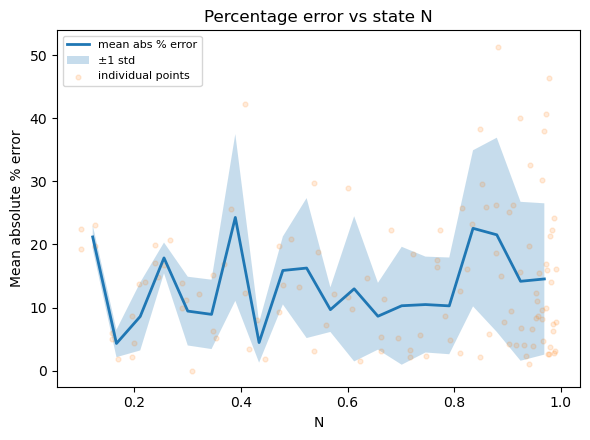


Mean percentage error by N bin
--------------------------------
N≈0.122 | mean % error = 21.182% | std =  1.870% | samples = 4
N≈0.167 | mean % error =  4.304% | std =  2.171% | samples = 3
N≈0.211 | mean % error =  8.583% | std =  5.383% | samples = 5
N≈0.256 | mean % error = 17.859% | std =  2.436% | samples = 5
N≈0.301 | mean % error =  9.432% | std =  5.446% | samples = 5
N≈0.345 | mean % error =  8.912% | std =  5.494% | samples = 3
N≈0.390 | mean % error = 24.271% | std = 13.215% | samples = 4
N≈0.434 | mean % error =  4.446% | std =  3.183% | samples = 3
N≈0.479 | mean % error = 15.869% | std =  5.381% | samples = 4
N≈0.523 | mean % error = 16.249% | std = 11.088% | samples = 4
N≈0.568 | mean % error =  9.662% | std =  3.534% | samples = 2
N≈0.612 | mean % error = 12.962% | std = 11.504% | samples = 4
N≈0.657 | mean % error =  8.618% | std =  5.293% | samples = 4
N≈0.702 | mean % error = 10.279% | std =  9.341% | samples = 5
N≈0.746 | mean % error = 10.469% | std =  7.595% | sa

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.10, 0.20, 0.17, 0.22,0.10]#, 0.20, 0.17, 0.22]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


def ar1_gaussian_nll(resid, sigma, rho, eps=1e-6, reduce="mean"):
    """
    AR(1) heteroscedastic Gaussian negative log-likelihood.

    Model:
        e_0 ~ N(0, sigma_0^2)
        e_k | e_{k-1} ~ N(rho e_{k-1}, (1-rho^2) sigma_k^2)

    Inputs
    ------
    resid : tensor
        Shape [T, 1] or [T]
    sigma : tensor
        Shape [T, 1] or [T]
    rho : float
        AR(1) correlation coefficient, |rho| < 1
    reduce : str
        "mean" or "sum"
    """
    resid = resid.reshape(-1)
    sigma = sigma.reshape(-1).clamp_min(eps)

    sigma2 = sigma ** 2
    one_minus_rho2 = max(1.0 - rho ** 2, eps)

    terms = []
    terms.append(torch.log(sigma2[0]) + resid[0] ** 2 / sigma2[0])

    innov = resid[1:] - rho * resid[:-1]
    var_innov = one_minus_rho2 * sigma2[1:]
    terms.append(torch.log(var_innov) + innov ** 2 / var_innov)

    terms = torch.cat([terms[0].view(1), terms[1]], dim=0)

    if reduce == "sum":
        return 0.5 * torch.sum(terms)
    elif reduce == "mean":
        return 0.5 * torch.mean(terms)
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def ar1_gaussian_nll_batch(resid_all, sigma_all, rho, eps=1e-6, reduce="mean"):
    """
    Batched AR(1) heteroscedastic Gaussian NLL.

    Inputs
    ------
    resid_all : tensor of shape [B, T, 1] or [B, T]
    sigma_all : tensor of shape [B, T, 1] or [B, T]
    """
    if resid_all.ndim == 2:
        resid_all = resid_all.unsqueeze(-1)
    if sigma_all.ndim == 2:
        sigma_all = sigma_all.unsqueeze(-1)

    B = resid_all.shape[0]
    losses = []
    for b in range(B):
        losses.append(ar1_gaussian_nll(resid_all[b], sigma_all[b], rho, eps=eps, reduce="mean"))

    losses = torch.stack(losses)

    if reduce == "mean":
        return losses.mean()
    elif reduce == "sum":
        return losses.sum()
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")
    
# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.07 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

noise_sig_coeff = 0.2
gamma = 1

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + noise_sig_coeff * torch.randn_like(y_true) * y_true**gamma

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = noise_sig_coeff * N_grid**gamma



# ============================================================
# Noise statistics
# ============================================================
with torch.no_grad():
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()   # [n_ics, numpts]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, numpts]

    noise_np = y_data_np - y_true_np
    abs_noise_np = np.abs(noise_np)

    # True sigma at observed states
    sigma_true_obs_np = (noise_sig_coeff * (y_true_all.squeeze(-1) ** gamma)).cpu().numpy()

    # Avoid divide-by-zero in percentage metrics
    eps = 1e-12
    denom_true = np.maximum(np.abs(y_true_np), eps)
    denom_sym = np.maximum(np.abs(y_true_np) + np.abs(y_data_np), eps)

    pct_error_np = 100.0 * noise_np / denom_true
    abs_pct_error_np = 100.0 * abs_noise_np / denom_true
    smape_np = 100.0 * 2.0 * abs_noise_np / denom_sym

    # Standardized noise using known sigma_true(N)
    z_np = noise_np / np.maximum(sigma_true_obs_np, eps)

    print("\nNoise summary: pooled over all ICs and times")
    print("--------------------------------------------")
    print(f"Mean signed noise                  : {noise_np.mean(): .6e}")
    print(f"Std of signed noise                : {noise_np.std(ddof=1): .6e}")
    print(f"Mean absolute noise                : {abs_noise_np.mean(): .6e}")
    print(f"Median absolute noise              : {np.median(abs_noise_np): .6e}")
    print(f"RMSE noise                         : {np.sqrt(np.mean(noise_np**2)): .6e}")
    print(f"Max absolute noise                 : {abs_noise_np.max(): .6e}")
    print(f"Mean percentage error (MPE)        : {pct_error_np.mean(): .6f}%")
    print(f"Mean abs percentage error (MAPE)   : {abs_pct_error_np.mean(): .6f}%")
    print(f"Median abs percentage error        : {np.median(abs_pct_error_np): .6f}%")
    print(f"Symmetric MAPE (sMAPE)             : {smape_np.mean(): .6f}%")
    print(f"Mean true sigma(N)                 : {sigma_true_obs_np.mean(): .6e}")
    print(f"Mean |noise| / sigma_true(N)       : {np.mean(abs_noise_np / np.maximum(sigma_true_obs_np, eps)): .6f}")
    print(f"Std of standardized noise z        : {z_np.std(ddof=1): .6f}")
    print(f"Mean of standardized noise z       : {z_np.mean(): .6f}")

    # print("\nPer-trajectory noise summary")
    # print("----------------------------")
    # for i in range(n_ics):
    #     noise_i = noise_np[i]
    #     abs_noise_i = abs_noise_np[i]
    #     pct_i = pct_error_np[i]
    #     apct_i = abs_pct_error_np[i]
    #     smape_i = smape_np[i]
    #     sigma_i = sigma_true_obs_np[i]
    #     z_i = z_np[i]

    #     print(f"\nTrajectory {i + 1} | IC = {N0_list[i]:.2f}")
    #     print(f"  Mean signed noise                : {noise_i.mean(): .6e}")
    #     print(f"  Std signed noise                 : {noise_i.std(ddof=1): .6e}")
    #     print(f"  Mean absolute noise              : {abs_noise_i.mean(): .6e}")
    #     print(f"  RMSE noise                       : {np.sqrt(np.mean(noise_i**2)): .6e}")
    #     print(f"  Mean percentage error            : {pct_i.mean(): .6f}%")
    #     print(f"  Mean abs percentage error        : {apct_i.mean(): .6f}%")
    #     print(f"  Symmetric MAPE                   : {smape_i.mean(): .6f}%")
    #     print(f"  Mean sigma_true(N)               : {sigma_i.mean(): .6e}")
    #     print(f"  Mean |noise|/sigma_true(N)       : {np.mean(abs_noise_i / np.maximum(sigma_i, eps)): .6f}")
    #     print(f"  Mean standardized noise z        : {z_i.mean(): .6f}")
    #     print(f"  Std standardized noise z         : {z_i.std(ddof=1): .6f}")


# ============================================================
# Optional: pointwise table of true/data/noise/%error
# ============================================================
print("\nObserved-point noise table")
print("--------------------------")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (IC = {N0_list[i]:.2f})")
    print("t        true        data        noise       abs%err     sigma_true    z=noise/sigma")
    for ti, yt, yd, en, ape, sigi, zi in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_np[i],
        y_data_np[i],
        noise_np[i],
        abs_pct_error_np[i],
        sigma_true_obs_np[i],
        z_np[i],
    ):
        print(
            f"{ti:6.3f}   {yt:9.5f}   {yd:9.5f}   {en:9.5f}   "
            f"{ape:9.3f}%   {sigi:11.5e}   {zi:9.4f}"
        )

# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def g_zero_nonnegative_penalty(dyn_net):
    """
    Keep the same form as before:
        penalty = sum(relu(-G(0))^2)
    This is zero when G(0) >= 0, and positive otherwise.
    """
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)

def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)



def g_zero_nonnegative_penalty(dyn_net):
    """
    Keep the same form as before:
        penalty = sum(relu(-G(0))^2)
    This is zero when G(0) >= 0, and positive otherwise.
    """
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)

def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=1000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    use_validation = val_fraction > 0.0 and n_samples > 1

    if use_validation:
        n_val = int(round(val_fraction * n_samples))
        n_val = max(1, min(n_val, n_samples - 1))
    else:
        n_val = 0
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        if use_validation:
            N_val = N_all[val_idx]
            r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
                criterion_name = "val"
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan
                criterion_name = "train"

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: N/A | Val NLL: N/A | Val Mon: N/A | "
                        f"Best-model criterion: training loss"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# Mean percentage error as a function of N
# ============================================================
with torch.no_grad():

    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    noise_np = y_data_np - y_true_np
    abs_noise_np = np.abs(noise_np)

    eps = 1e-12
    abs_pct_error_np = 100.0 * abs_noise_np / np.maximum(np.abs(y_true_np), eps)

    # Flatten all trajectories
    N_flat = y_true_np.reshape(-1)
    pct_flat = abs_pct_error_np.reshape(-1)

    # Bin in N
    n_bins = 20
    bins = np.linspace(N_flat.min(), N_flat.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    mean_pct = np.zeros(n_bins)
    std_pct = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for i in range(n_bins):
        mask = (N_flat >= bins[i]) & (N_flat < bins[i + 1])

        if np.sum(mask) > 0:
            mean_pct[i] = pct_flat[mask].mean()
            std_pct[i] = pct_flat[mask].std(ddof=1)
            counts[i] = np.sum(mask)
        else:
            mean_pct[i] = np.nan
            std_pct[i] = np.nan
            counts[i] = 0


# ============================================================
# Plot mean percentage error vs N
# ============================================================
plt.figure(figsize=(6,4.5))

plt.plot(bin_centers, mean_pct, linewidth=2, label="mean abs % error")

plt.fill_between(
    bin_centers,
    mean_pct - std_pct,
    mean_pct + std_pct,
    alpha=0.25,
    label="±1 std"
)

plt.scatter(N_flat, pct_flat, s=12, alpha=0.15, label="individual points")

plt.xlabel("N")
plt.ylabel("Mean absolute % error")
plt.title("Percentage error vs state N")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# Print numeric summary
# ============================================================
print("\nMean percentage error by N bin")
print("--------------------------------")
for c, m, s, n in zip(bin_centers, mean_pct, std_pct, counts):
    if n > 0:
        print(f"N≈{c:.3f} | mean % error = {m:6.3f}% | std = {s:6.3f}% | samples = {int(n)}")



Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.10
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
PINN | Split  1/5 | Epoch     1/5000 | PINN Total: 7.258698e-01 | Optim Total: 7.258698e-01 | Train Data: 7.216772e-01 | Train Phys: 4.192628e-03 | Train IC[N(0)]: 2.861643e-02 | Heldout Rollout Val: 4.754550e-01
PINN | Split  1/5 | Epoch   500/5000 | PINN Total: 1.775351e-02 | Optim Total: 1.775351e-02 | Train Data: 1.726583e-02 | Train Phys: 4.876796e-04 | Train IC[N(0)]: 2.933820e-03 | Heldout Rollout Val: 2.954133e-02
PINN | Split  1/5 | Epoch  1000/5000 | PINN Total: 1.746913e-02 | Optim Total: 1.746913e-02 | Train Data: 1.690599e-02 | Train Phys: 5.631385e-04 | Train IC[N(0)]: 2.827888e-03 | Heldout Rollout Val: 2.842681e-02
PINN | Split  1/5 | Epoch  1500/5000 | PINN Total: 1.716516e-02 | Optim Total: 1.716516e-02 | Train Data: 1.660848e-02 | Train Phys: 5.566755e

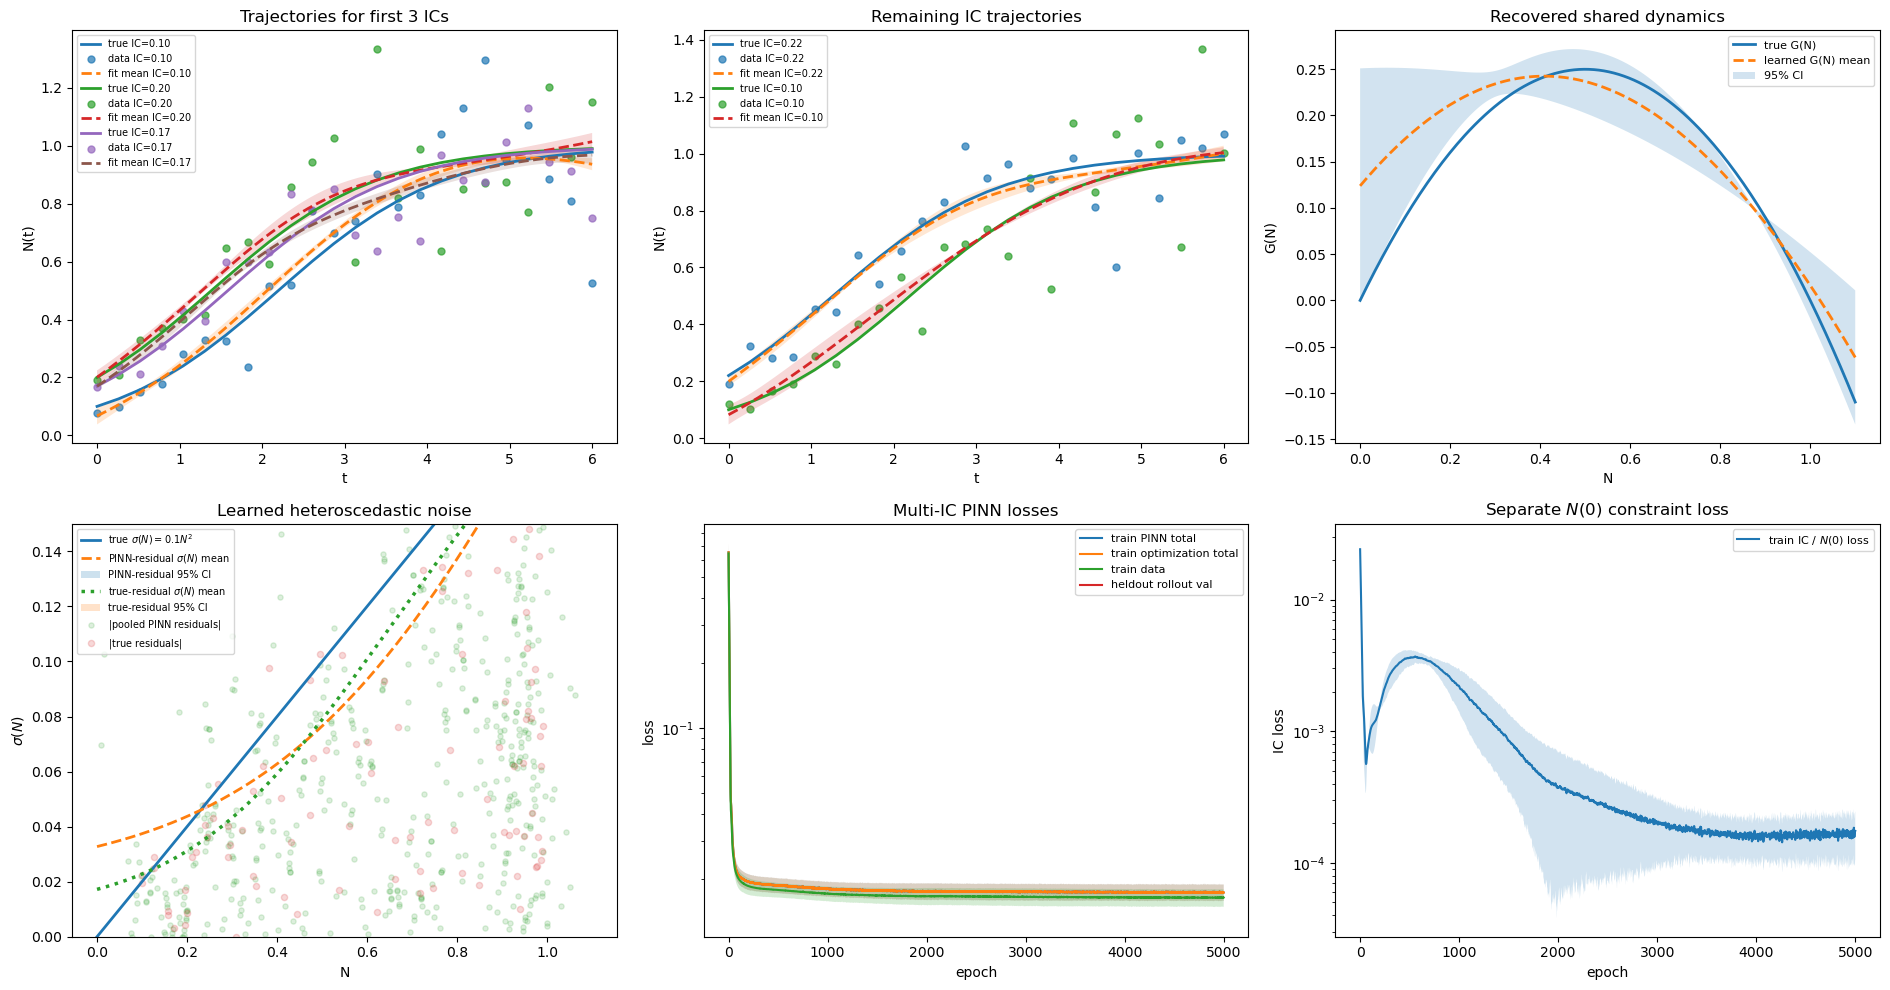

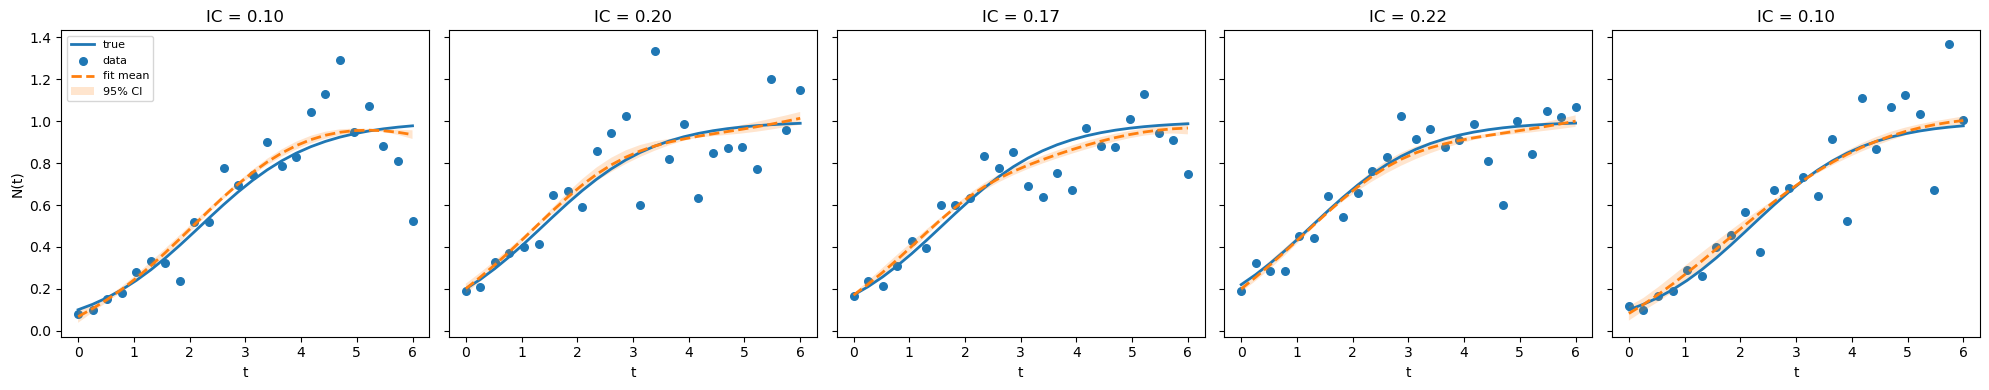

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_17962/689474724.py:863: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


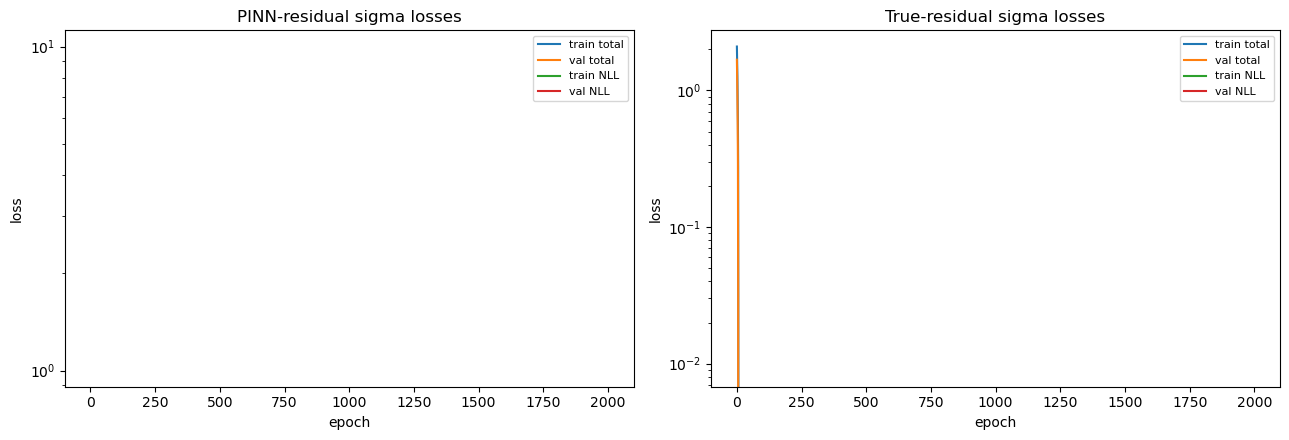

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 5
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22, 0.1]
Number of PINN splits: 5
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 1.936745e-02
Std  best validation loss: 7.389401e-03
Mean best epoch: 2119.00
Std  best epoch: 1675.41
IC/N(0) loss weight lambda_ic: 0.000
PINN loss used for model fitting/selection: data + lambda_phys * physics
Separate optimization term: lambda_ic * IC/N(0) loss

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003, 20004]
Split 2: heldout_ic=1, dyn_init_seed=10001, sol_init_seeds=[21000, 21002, 21003, 21004]
Split 3: heldout_ic=2, dyn_init_seed=10002, sol_init_seeds=[22000, 22001, 22003, 22004]
Split 4: heldout_ic=3, dyn_init_seed=10003, sol_init_seeds=[2300

In [23]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res

def g_zero_nonnegative_penalty(dyn_net):
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)

@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = dyn_net(N) from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(lambda tt, yy: dyn_net(yy), y0, t.squeeze()).squeeze(1)
    return y_roll


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                print(
                    f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_total.item():.6e} | "
                    f"Train NLL: {train_nll.item():.6e} | "
                    f"Train Mon: {train_mon.item():.6e} | "
                    f"Val Total: {val_total.item():.6e} | "
                    f"Val NLL: {val_nll.item():.6e} | "
                    f"Val Mon: {val_mon.item():.6e}"
                )

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - IMPORTANT UPDATE:
#         the N(0) constraint is treated as a separate loss term
#         and is NOT included in the PINN loss used for model selection
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 5000
n_splits = n_ics
print_every = 500
val_every = 100

batch_obs = t_obs.shape[0]
batch_col = 100

lambda_phys = 1.0
lambda_ic = 0.0   # separate IC/N(0) loss weight; not part of PINN loss
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_pinn_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_optim_total_histories = []

val_total_histories = []
val_eval_mask_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_pinn_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_optim_total_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_ic_loss = 0.0

        # ----------------------------------------------------
        # Train only on non-held-out trajectories
        # ----------------------------------------------------
        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)
            phys_loss = phys_loss + g_zero_nonnegative_penalty(dyn_net)

            # ------------------------------------------------
            # Separate initial-condition / N(0) loss
            # ------------------------------------------------
            t0 = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
            y0_target = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0)
            ic_loss = torch.mean((N0_pred - y0_target) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_ic_loss += ic_loss

        total_data_loss /= n_train_ics
        total_phys_loss /= n_train_ics
        total_ic_loss /= n_train_ics

        # PINN loss excludes the N(0) term
        pinn_loss = total_data_loss + lambda_phys * total_phys_loss

        # Optimization loss includes the separate N(0) term if desired
        optim_loss = pinn_loss + lambda_ic * total_ic_loss

        optim_loss.backward()
        optimizer.step()

        train_pinn_total_history.append(pinn_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_ic_history.append(total_ic_loss.item())
        train_optim_total_history.append(optim_loss.item())

        # ----------------------------------------------------
        # Held-out trajectory validation via forward rollout
        # ----------------------------------------------------
        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                y0_val = y_data_all[heldout_ic][0:1]
                y_val_target = y_data_all[heldout_ic]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"PINN Total: {pinn_loss.item():.6e} | "
                f"Optim Total: {optim_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train IC[N(0)]: {total_ic_loss.item():.6e} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_pinn_total_histories.append(train_pinn_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_optim_total_histories.append(train_optim_total_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_pinn_total_histories = np.array(train_pinn_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_optim_total_histories = np.array(train_optim_total_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(train_pinn_total_histories)
train_optim_total_mean, train_optim_total_lo, train_optim_total_hi = mean_and_ci(train_optim_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)

axes[1, 1].plot(epochs_init, train_pinn_total_mean, label="train PINN total")
axes[1, 1].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_optim_total_mean, label="train optimization total")
axes[1, 1].fill_between(epochs_init, train_optim_total_lo, train_optim_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Separate N(0) loss
# ------------------------------------------------------------
train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
axes[1, 2].plot(epochs_init, train_ic_mean, label=r"train IC / $N(0)$ loss")
axes[1, 2].fill_between(epochs_init, train_ic_lo, train_ic_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("IC loss")
axes[1, 2].set_title(r"Separate $N(0)$ constraint loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"IC/N(0) loss weight lambda_ic: {lambda_ic:.3f}")
print("PINN loss used for model fitting/selection: data + lambda_phys * physics")
print("Separate optimization term: lambda_ic * IC/N(0) loss")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )


SR dataset sizes
----------------
From solution-net derivatives: X shape = (200, 1), y shape = (200,)
From noisy measurements       : X shape = (120, 1), y shape = (120,)


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (


Expressions evaluated per second: 2.050e+05
Progress: 622 / 800 total iterations (77.750%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.256e-03  1.594e+01  y = 0.13659
4           2.564e-03  3.898e-01  y = sqrt(x₀) - x₀
5           2.406e-04  2.366e+00  y = (0.98982 - x₀) * x₀
7           2.053e-05  1.231e+00  y = x₀ * ((x₀ * -1.1299) + 1.1005)
8           1.354e-05  4.166e-01  y = ((x₀ * -1.1956) + 1.1774) * tanh(x₀)
9           8.735e-06  4.382e-01  y = (1.9741 - (x₀ + (x₀ ^ 0.086579))) * x₀
10          6.207e-06  3.417e-01  y = (tanh(x₀) * ((x₀ * -1.2339) + 1.2309)) - 0.013736
───────────────────────────────────────────────────────────────────────────────────────────────────
═══════════════════════════════════════════════════════════════════════════════════════════════════

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only

  - outputs/20260311_161314_zYNqnP/hall_of_fame.csv


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.000e+05
Progress: 594 / 800 total iterations (74.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.773e-04  1.594e+01  y = 0.11413
4           7.115e-05  8.373e-01  y = 0.2109 / exp(x₀)
5           2.858e-07  5.517e+00  y = (0.90429 ^ x₀) + -0.81993
6           2.627e-08  2.387e+00  y = tanh(0.80752 ^ x₀) + -0.58405
8           7.269e-09  6.423e-01  y = tanh((0.44341 ^ (1.2979 ^ x₀)) + -0.26363)
9           5.254e-09  3.246e-01  y = tanh(tanh(0.34785 ^ (1.362 ^ x₀))) + -0.1447
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.
──────────────

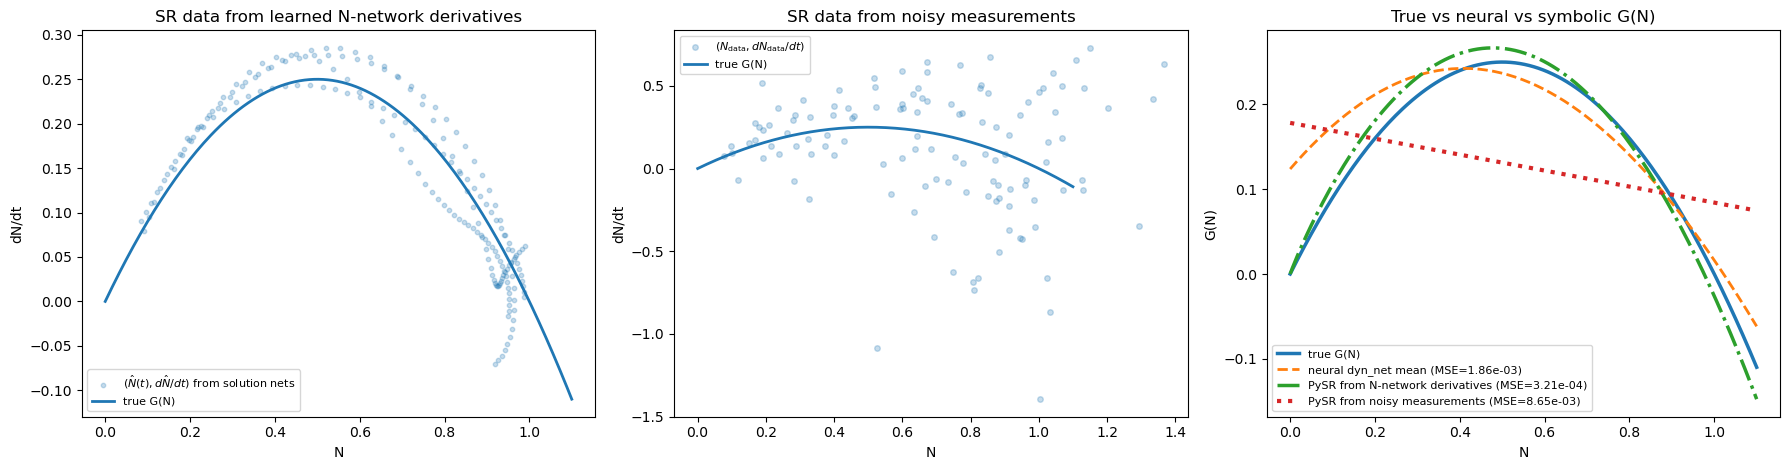


Selected equation from solution-net derivatives:
complexity                                                       9
loss                                                      0.000009
equation               (1.9740726 - (x0 + (x0 ^ 0.08657937))) * x0
score                                                      0.43817
sympy_format                x0*(1.9740726 - (x0**0.08657937 + x0))
lambda_format    PySRFunction(X=>x0*(1.9740726 - (x0**0.0865793...
Name: 5, dtype: object

Selected equation from noisy measurements:
complexity                                                       7
loss                                                           0.0
equation                tanh(tanh(x0 * -0.096070856) + 0.18019827)
score                                                     1.702873
sympy_format            tanh(tanh(x0*(-0.096070856)) + 0.18019827)
lambda_format    PySRFunction(X=>tanh(tanh(x0*(-0.096070856)) +...
Name: 3, dtype: object
  - outputs/20260311_161329_7eaP2Q/hall_of_fame.csv


In [24]:
# ============================================================
# 13. Symbolic regression (PySR) for G(N)
#     (A) using dN/dt from the learned N-network (solution nets)
#     (B) using finite-difference derivatives from noisy measurements directly
#
# Paste this AFTER your existing script.
#
# Requirement:
#   pip install pysr
#
# Notes:
# - Method A uses (N_hat(t), dN_hat/dt) from the trained solution networks.
# - Method B uses (N_data(t), dN_data/dt) where dN_data/dt is estimated by
#   finite differences on the noisy measurements.
# - Both are compared to the true G(N)=rN(1-N) via plots and MSE on N_grid.
# ============================================================

from pysr import PySRRegressor

# ------------------------------------------------------------
# Helper: rebuild the best PINN solution networks from best_states
# ------------------------------------------------------------
def rebuild_best_solnets(best_state, n_ics, hidden_dim_sol, device):
    solnet_list = []
    for i in range(n_ics):
        net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
        net.load_state_dict(best_state["sol_nets"][i])
        net.eval()
        solnet_list.append(net)
    return solnet_list


# ------------------------------------------------------------
# Helper: collect SR data from solution nets
#   X = N_hat(t), y = dN_hat/dt
# ------------------------------------------------------------
def collect_sr_data_from_solution_nets(solnet_list, t_eval):
    X_all = []
    y_all = []

    for sol_net in solnet_list:
        t_req = t_eval.clone().detach().requires_grad_(True)
        N_hat = sol_net(t_req)

        dN_dt_hat = torch.autograd.grad(
            outputs=N_hat,
            inputs=t_req,
            grad_outputs=torch.ones_like(N_hat),
            create_graph=False,
            retain_graph=False,
        )[0]

        X_all.append(N_hat.detach().cpu().numpy())
        y_all.append(dN_dt_hat.detach().cpu().numpy())

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.vstack(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    mask &= X_all[:, 0] >= 0.0

    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: collect SR data directly from noisy measurements
#   X = N_data(t), y = dN_data/dt via finite differences
# ------------------------------------------------------------
def collect_sr_data_from_noisy_measurements(y_data_all, t_obs):
    t_np = t_obs.squeeze(1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, numpts]

    X_all = []
    y_all = []

    for i in range(y_data_np.shape[0]):
        y_i = y_data_np[i]
        dy_dt_i = np.gradient(y_i, t_np)  # central diff interior, 1-sided endpoints

        X_all.append(y_i.reshape(-1, 1))
        y_all.append(dy_dt_i.reshape(-1))

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.concatenate(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    mask &= X_all[:, 0] >= 0.0

    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: fit PySR
# ------------------------------------------------------------
def fit_pysr_1d(X, y, niterations=200, populations=20, maxsize=18, random_state=0):
    model = PySRRegressor(
        niterations=niterations,
        populations=populations,
        population_size=50,
        maxsize=maxsize,
        model_selection="best",
        loss="loss(prediction, target) = (prediction - target)^2",
        binary_operators=["+", "-", "*", "/", "^"],
        unary_operators=["exp", "log", "sqrt", "tanh"],
        batching=False,
        turbo=True,
        progress=True,
        random_state=random_state,
        deterministic=True,
        parallelism="serial",   # <-- required with deterministic=True,
        denoise=True,           # added
        warm_start=False,
    )
    model.fit(X, y)
    return model

# ------------------------------------------------------------
# Helper: safe prediction
# ------------------------------------------------------------
def safe_predict(model, X):
    y = model.predict(X)
    y = np.asarray(y).reshape(-1)
    return y


# ------------------------------------------------------------
# Choose the best PINN split, rebuild sol_nets, and create SR datasets
# ------------------------------------------------------------
best_split_idx = int(np.argmin(best_val_losses))
best_state_for_sr = best_states[best_split_idx]

solnets_best = rebuild_best_solnets(
    best_state=best_state_for_sr,
    n_ics=n_ics-1,
    hidden_dim_sol=hidden_dim_sol,
    device=device,
)

# Dense time grid for the derivative-based SR dataset from the learned N-networks
t_sr_dense = torch.linspace(0.0, 6.0, 50, device=device).view(-1, 1)

X_pinn_sr, y_pinn_sr = collect_sr_data_from_solution_nets(solnets_best, t_sr_dense)
X_noisy_sr, y_noisy_sr = collect_sr_data_from_noisy_measurements(y_data_all, t_obs)

print("\nSR dataset sizes")
print("----------------")
print(f"From solution-net derivatives: X shape = {X_pinn_sr.shape}, y shape = {y_pinn_sr.shape}")
print(f"From noisy measurements       : X shape = {X_noisy_sr.shape}, y shape = {y_noisy_sr.shape}")

# ------------------------------------------------------------
# Fit PySR models
# ------------------------------------------------------------
pysr_pinn = fit_pysr_1d(
    X_pinn_sr,
    y_pinn_sr,
    niterations=40,
    populations=20,
    maxsize=10,
    random_state=123,
)

pysr_noisy = fit_pysr_1d(
    X_noisy_sr,
    y_noisy_sr,
    niterations=40,
    populations=20,
    maxsize=10,
    random_state=456,
)

print("\nBest symbolic model from solution-net derivatives")
print("--------------------------------------------------")
print(pysr_pinn)

print("\nBest symbolic model from noisy measurements")
print("-------------------------------------------")
print(pysr_noisy)

# ------------------------------------------------------------
# Evaluate both symbolic models on N_grid and compare to true G
# ------------------------------------------------------------
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
G_true_np = G_true(N_grid).detach().cpu().numpy().reshape(-1)

G_sr_pinn_np = safe_predict(pysr_pinn, N_grid_np)
G_sr_noisy_np = safe_predict(pysr_noisy, N_grid_np)

mse_sr_pinn = np.mean((G_sr_pinn_np - G_true_np) ** 2)
mse_sr_noisy = np.mean((G_sr_noisy_np - G_true_np) ** 2)
mse_nn = np.mean((rhs_mean - G_true_np) ** 2)

print("\nMSE on N_grid against true G")
print("----------------------------")
print(f"Neural dyn_net mean MSE           : {mse_nn:.6e}")
print(f"PySR from solution-net dN/dt MSE  : {mse_sr_pinn:.6e}")
print(f"PySR from noisy finite-diff MSE   : {mse_sr_noisy:.6e}")

# ------------------------------------------------------------
# Plot datasets used by SR and final recovered G(N)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Dataset from solution nets
axes[0].scatter(
    X_pinn_sr[:, 0],
    y_pinn_sr,
    s=10,
    alpha=0.25,
    label=r"$(\hat N(t), d\hat N/dt)$ from solution nets",
)
axes[0].plot(
    N_grid_np[:, 0],
    G_true_np,
    linewidth=2,
    label="true G(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("dN/dt")
axes[0].set_title("SR data from learned N-network derivatives")
axes[0].legend(fontsize=8)

# Dataset from noisy measurements
axes[1].scatter(
    X_noisy_sr[:, 0],
    y_noisy_sr,
    s=16,
    alpha=0.25,
    label=r"$(N_{\mathrm{data}}, dN_{\mathrm{data}}/dt)$",
)
axes[1].plot(
    N_grid_np[:, 0],
    G_true_np,
    linewidth=2,
    label="true G(N)",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("dN/dt")
axes[1].set_title("SR data from noisy measurements")
axes[1].legend(fontsize=8)

# Final comparison
axes[2].plot(
    N_grid_np[:, 0],
    G_true_np,
    linewidth=2.5,
    label="true G(N)",
)
axes[2].plot(
    N_grid_np[:, 0],
    rhs_mean,
    "--",
    linewidth=2,
    label=f"neural dyn_net mean (MSE={mse_nn:.2e})",
)
axes[2].plot(
    N_grid_np[:, 0],
    G_sr_pinn_np,
    "-.",
    linewidth=2.5,
    label=f"PySR from N-network derivatives (MSE={mse_sr_pinn:.2e})",
)
axes[2].plot(
    N_grid_np[:, 0],
    G_sr_noisy_np,
    ":",
    linewidth=3.0,
    label=f"PySR from noisy measurements (MSE={mse_sr_noisy:.2e})",
)
axes[2].set_xlabel("N")
axes[2].set_ylabel("G(N)")
axes[2].set_title("True vs neural vs symbolic G(N)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: print the selected equations more explicitly
# ------------------------------------------------------------
try:
    print("\nSelected equation from solution-net derivatives:")
    print(pysr_pinn.get_best())

    print("\nSelected equation from noisy measurements:")
    print(pysr_noisy.get_best())
except Exception as e:
    print("\nCould not print get_best() details.")
    print(f"Reason: {e}")


Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.10
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
PINN | Split  1/5 | Epoch     1/3000 | PINN Total: 7.242503e-01 | Optim Total: 7.242503e-01 | Train Data: 7.216772e-01 | Train Phys: 2.573130e-03 | Train IC[N(0)]: 2.861643e-02 | Heldout Rollout Val: 4.302463e-01
PINN | Split  1/5 | Epoch   500/3000 | PINN Total: 1.769743e-02 | Optim Total: 1.769743e-02 | Train Data: 1.723949e-02 | Train Phys: 4.579368e-04 | Train IC[N(0)]: 2.935481e-04 | Heldout Rollout Val: 3.062420e-02
PINN | Split  1/5 | Epoch  1000/3000 | PINN Total: 1.716544e-02 | Optim Total: 1.716544e-02 | Train Data: 1.664540e-02 | Train Phys: 5.200432e-04 | Train IC[N(0)]: 1.952813e-04 | Heldout Rollout Val: 2.583124e-02
PINN | Split  1/5 | Epoch  1500/3000 | PINN Total: 1.699217e-02 | Optim Total: 1.699217e-02 | Train Data: 1.646676e-02 | Train Phys: 5.254121e

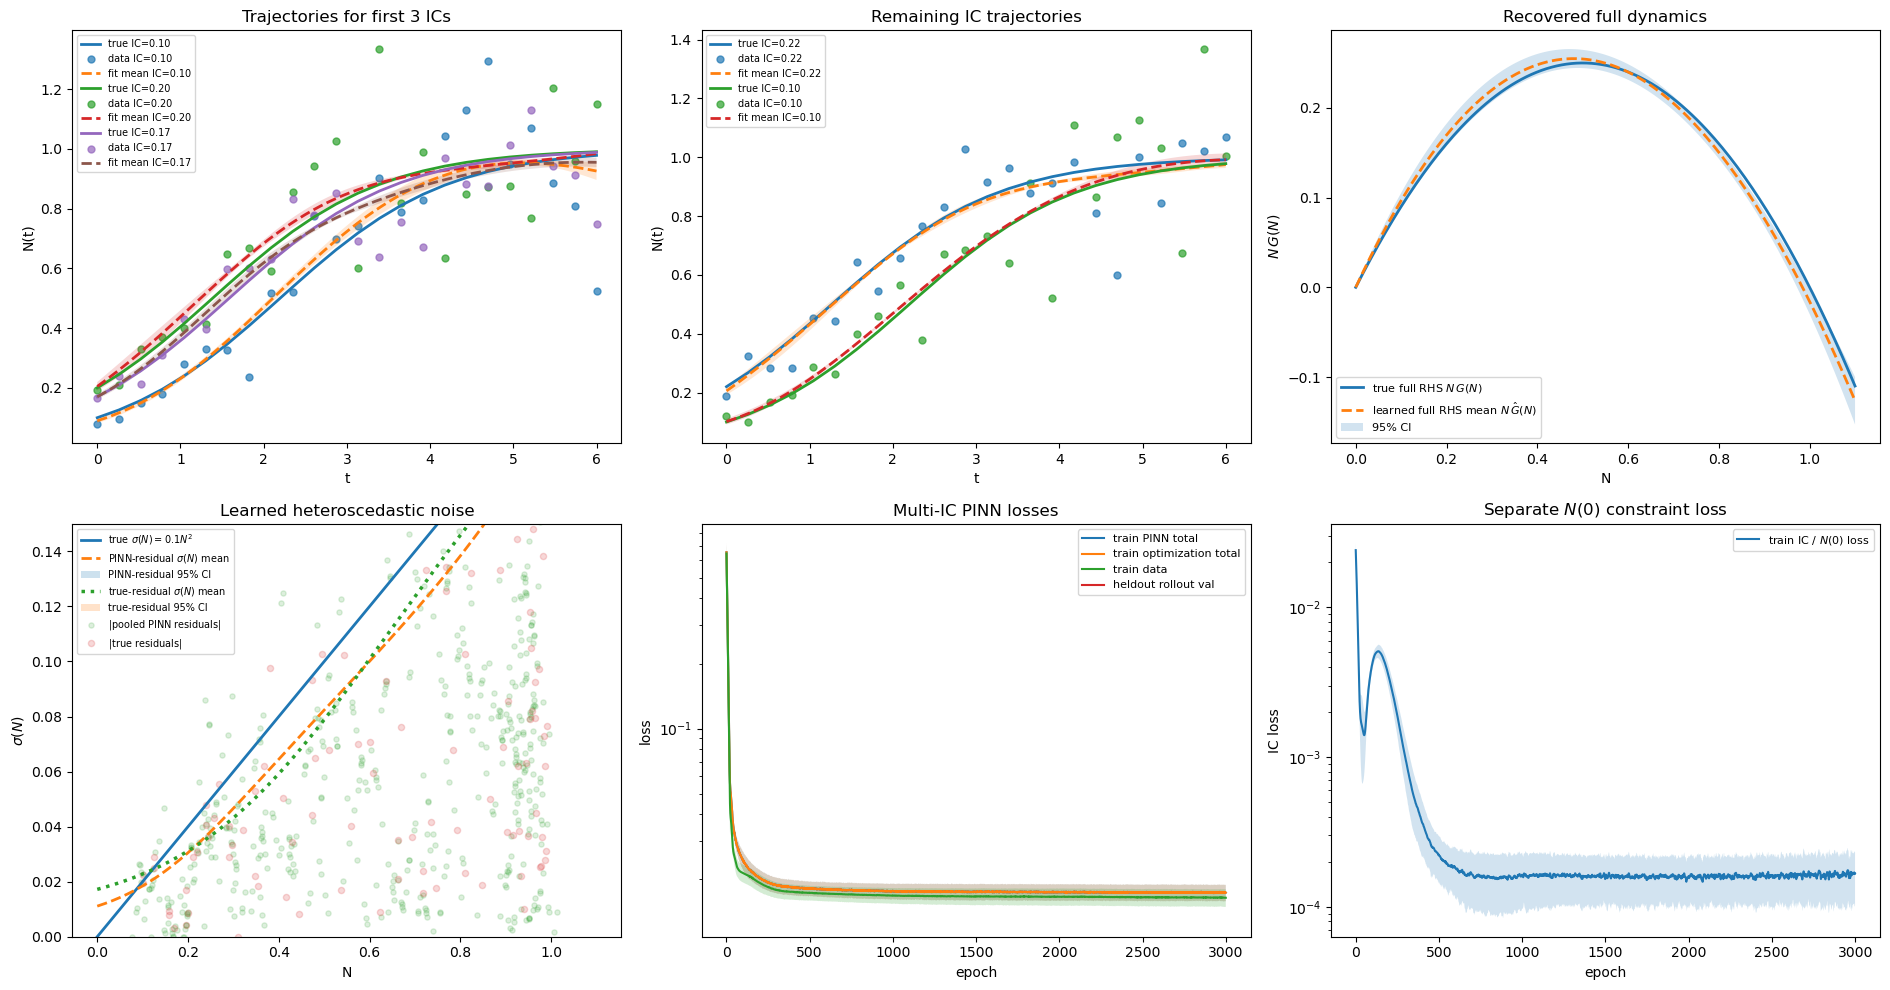

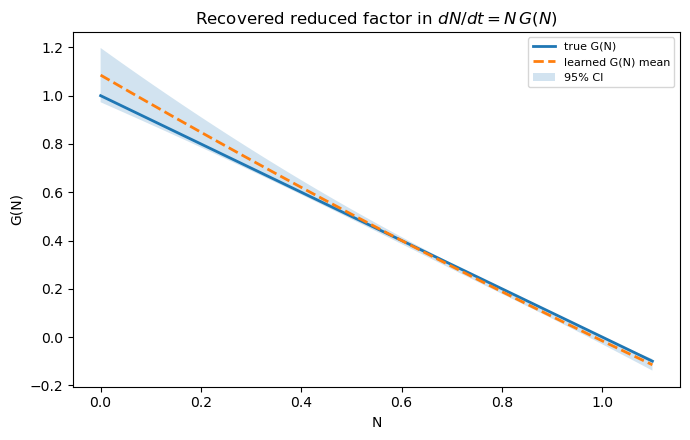

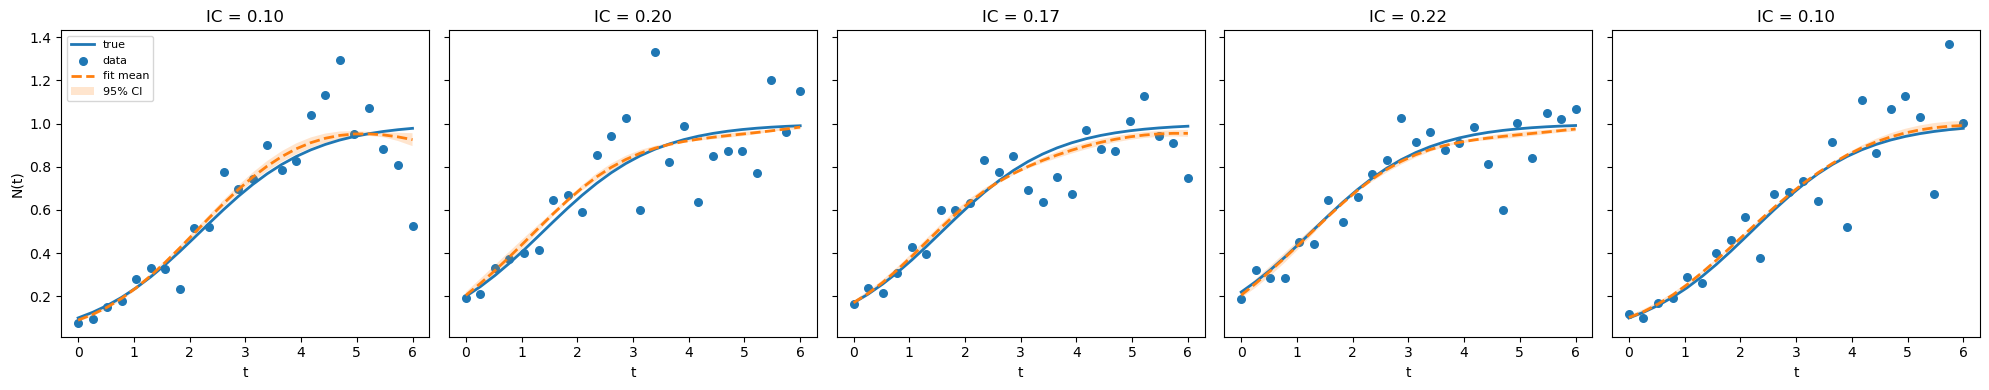

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_17962/2608238259.py:741: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


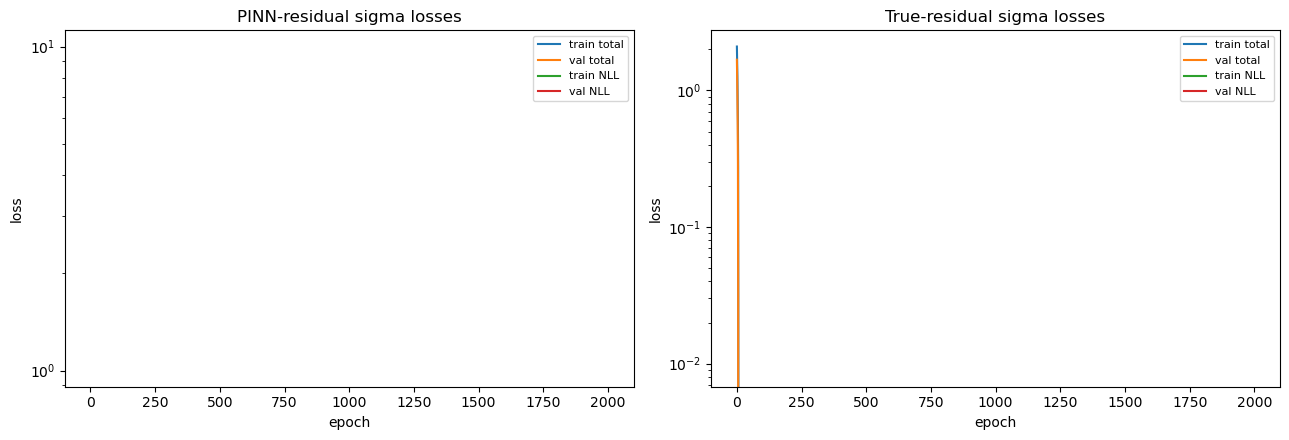

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 5
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22, 0.1]
Number of PINN splits: 5
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 1.931213e-02
Std  best validation loss: 7.117124e-03
Mean best epoch: 1759.00
Std  best epoch: 1337.16
IC/N(0) loss weight lambda_ic: 0.000
Model structure: dN/dt = N * G(N), with dyn_net learning G(N)
PINN loss used for model fitting/selection: data + lambda_phys * physics
Separate optimization term: lambda_ic * IC/N(0) loss

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003, 20004]
Split 2: heldout_ic=1, dyn_init_seed=10001, sol_init_seeds=[21000, 21002, 21003, 21004]
Split 3: heldout_ic=2, dyn_init_seed=10002, sol_init_seeds=[22000, 22001, 22003, 22004]
Sp

In [25]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# True dynamics for RHS structure dN/dt = N * G(N)
# ============================================================
r_true = 1.0

def G_true(N):
    # logistic written as dN/dt = N * G(N)
    return r_true * (1.0 - N)

def RHS_true(N):
    # full RHS
    return N * G_true(N)


def pinn_physics_residual(sol_net, dyn_net, t_col):
    """
    Model structure:
        dN/dt = N * G(N)
    where dyn_net(N) approximates the reduced factor G(N).
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    g_pred = dyn_net(N_pred_col)
    rhs_pred = N_pred_col * g_pred
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, g_pred, rhs_pred, phys_res


def g_zero_nonnegative_penalty(dyn_net):
    """
    Optional penalty on the reduced factor G(0).
    Note: with dN/dt = N*G(N), the full RHS is automatically zero at N=0.
    This penalty only enforces G(0) >= 0, if desired.
    """
    N_zero = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)


@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = N * dyn_net(N) from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(lambda tt, yy: yy * dyn_net(yy), y0, t.squeeze()).squeeze(1)
    return y_roll




# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net learning the reduced factor G(N)
#    - full RHS is N * G(N)
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - N(0) constraint treated as separate loss term
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 3000
n_splits = n_ics
print_every = 500
val_every = 100

batch_obs = t_obs.shape[0]
batch_col = 100

lambda_phys = 1.0
lambda_ic = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_pinn_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_optim_total_histories = []

val_total_histories = []
val_eval_mask_histories = []

traj_histories = []
rhs_histories = []         # full RHS = N * G(N)
gfactor_histories = []     # reduced factor = G(N)
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_pinn_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_optim_total_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_ic_loss = 0.0

        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)
            phys_loss = phys_loss + g_zero_nonnegative_penalty(dyn_net)

            t0 = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
            y0_target = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0)
            ic_loss = torch.mean((N0_pred - y0_target) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_ic_loss += ic_loss

        total_data_loss /= n_train_ics
        total_phys_loss /= n_train_ics
        total_ic_loss /= n_train_ics

        pinn_loss = total_data_loss + lambda_phys * total_phys_loss
        optim_loss = pinn_loss + lambda_ic * total_ic_loss

        optim_loss.backward()
        optimizer.step()

        train_pinn_total_history.append(pinn_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_ic_history.append(total_ic_loss.item())
        train_optim_total_history.append(optim_loss.item())

        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                y0_val = y_data_all[heldout_ic][0:1]
                y_val_target = y_data_all[heldout_ic]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"PINN Total: {pinn_loss.item():.6e} | "
                f"Optim Total: {optim_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train IC[N(0)]: {total_ic_loss.item():.6e} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        G_factor_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()
        rhs_grid_learned = N_grid.squeeze(1).cpu().numpy() * G_factor_grid_learned

    train_pinn_total_histories.append(train_pinn_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_optim_total_histories.append(train_optim_total_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(rhs_grid_learned)
    gfactor_histories.append(G_factor_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_pinn_total_histories = np.array(train_pinn_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_optim_total_histories = np.array(train_optim_total_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
gfactor_histories = np.array(gfactor_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
gfactor_mean, gfactor_lo, gfactor_hi = mean_and_ci(gfactor_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

axes[0, 2].plot(
    N_grid.cpu().numpy(),
    RHS_true(N_grid).squeeze(1).cpu().numpy(),
    label=r"true full RHS $N\,G(N)$",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label=r"learned full RHS mean $N\,\hat G(N)$",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel(r"$N\,G(N)$")
axes[0, 2].set_title("Recovered full dynamics")
axes[0, 2].legend(fontsize=8)

axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

epochs_init = np.arange(n_epochs)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(train_pinn_total_histories)
train_optim_total_mean, train_optim_total_lo, train_optim_total_hi = mean_and_ci(train_optim_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)

axes[1, 1].plot(epochs_init, train_pinn_total_mean, label="train PINN total")
axes[1, 1].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_optim_total_mean, label="train optimization total")
axes[1, 1].fill_between(epochs_init, train_optim_total_lo, train_optim_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
axes[1, 2].plot(epochs_init, train_ic_mean, label=r"train IC / $N(0)$ loss")
axes[1, 2].fill_between(epochs_init, train_ic_lo, train_ic_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("IC loss")
axes[1, 2].set_title(r"Separate $N(0)$ constraint loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true(N_grid).squeeze(1).cpu().numpy(),
    linewidth=2,
    label="true G(N)",
)
plt.plot(
    N_grid.cpu().numpy(),
    gfactor_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    gfactor_lo,
    gfactor_hi,
    alpha=0.20,
    label="95% CI",
)
plt.xlabel("N")
plt.ylabel("G(N)")
plt.title(r"Recovered reduced factor in $dN/dt = N\,G(N)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"IC/N(0) loss weight lambda_ic: {lambda_ic:.3f}")
print("Model structure: dN/dt = N * G(N), with dyn_net learning G(N)")
print("PINN loss used for model fitting/selection: data + lambda_phys * physics")
print("Separate optimization term: lambda_ic * IC/N(0) loss")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )

best_split_idx: 3
n_ics (global): 5
saved sol_nets: 4
Checkpoint contains 4 solution nets.

SR dataset sizes
----------------
From solution-net derivatives: X shape = (200, 1), y shape = (200,)
From noisy measurements       : X shape = (120, 1), y shape = (120,)


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}


Expressions evaluated per second: 2.000e+05
Progress: 596 / 800 total iterations (74.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.021e-01  1.594e+01  y = 0.40463
3           1.610e-03  2.075e+00  y = 1.0251 - x₀
5           8.894e-05  1.448e+00  y = tanh(log(x₀ ^ -0.8713))
7           8.462e-05  2.491e-02  y = tanh((log(x₀) - -0.0040943) * -0.87753)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.021e-01  1.594e+01

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only

  - outputs/20260311_164144_RR2LEQ/hall_of_fame.csv


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
<lambdifygenerated-17>:2: RuntimeWarning: invalid value encountered in power
  return ((0.9850779 - x0)/0.87922734)**1.0442038



Expressions evaluated per second: 2.220e+05
Progress: 671 / 800 total iterations (83.875%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.117e-01  1.594e+01  y = 0.30818
3           1.562e-02  9.836e-01  y = 0.99118 - x₀
4           8.265e-03  6.368e-01  y = log(x₀ ^ -0.53881)
5           9.919e-04  2.120e+00  y = 0.015555 ^ (x₀ ^ 2.3375)
7           9.413e-04  2.620e-02  y = 0.014686 ^ sqrt(tanh(x₀ ^ 4.7054))
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss     

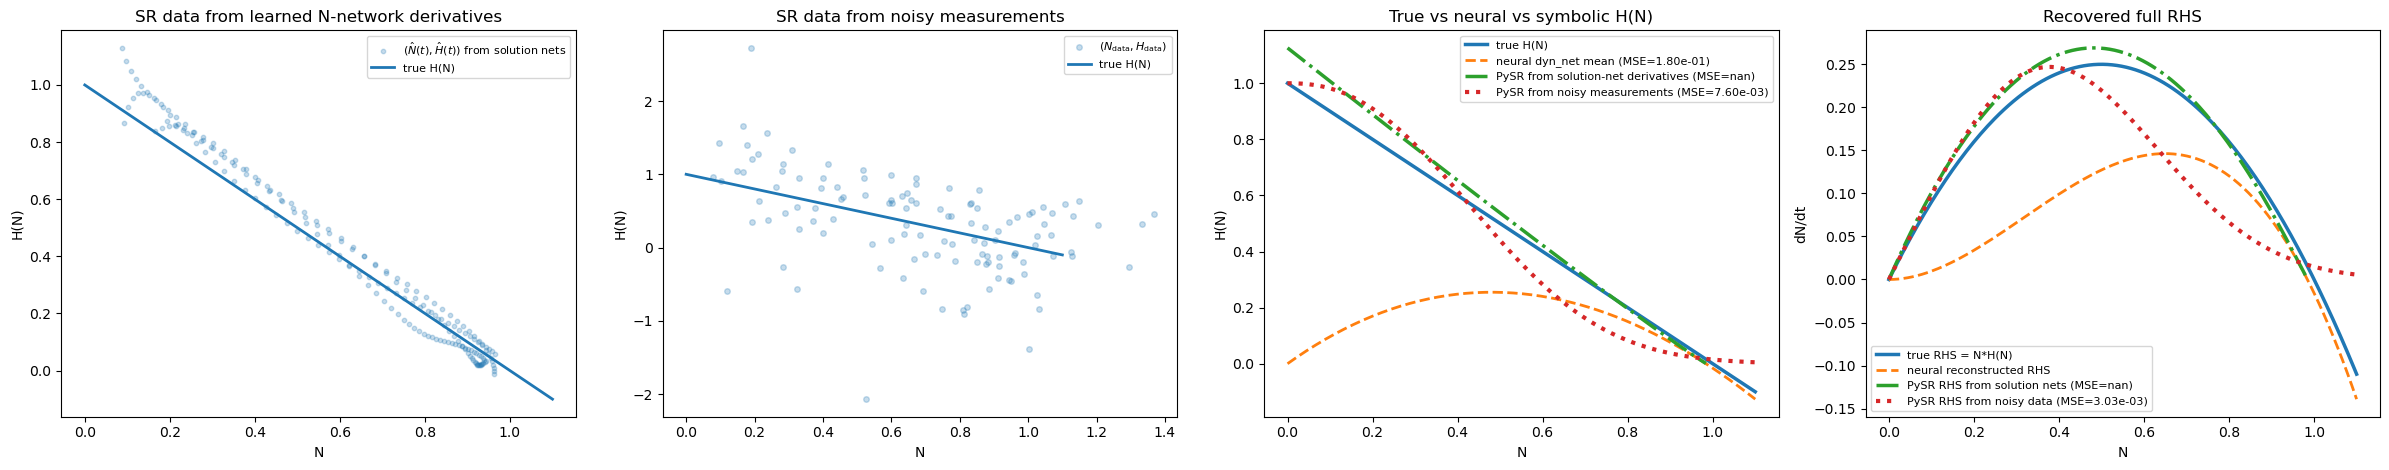


Selected equation for H(N) from solution-net derivatives:
complexity                                                       7
loss                                                      0.000003
equation               ((0.9850779 - x0) / 0.87922734) ^ 1.0442038
score                                                     1.015188
sympy_format              ((0.9850779 - x0)/0.87922734)**1.0442038
lambda_format    PySRFunction(X=>((0.9850779 - x0)/0.87922734)*...
Name: 3, dtype: object

Selected equation for H(N) from noisy measurements:
complexity                                                   5
loss                                                  0.000992
equation                        0.014774018 ^ (x0 ^ 2.3569274)
score                                                  2.12033
sympy_format                      0.014774018**(x0**2.3569274)
lambda_format    PySRFunction(X=>0.014774018**(x0**2.3569274))
Name: 3, dtype: object
  - outputs/20260311_164200_btSNhw/hall_of_fame.csv


In [28]:
# ============================================================
# 13. Symbolic regression (PySR) for H(N), where
#         dN/dt = N * H(N)
#
#     (A) using dN/dt from the learned N-network (solution nets)
#     (B) using finite-difference derivatives from noisy measurements directly
#
# Requirement:
#   pip install pysr
#
# Notes:
# - Method A uses (N_hat(t), H_hat(t)) with H_hat = (dN_hat/dt)/N_hat
# - Method B uses (N_data(t), H_data(t)) with H_data = (dN_data/dt)/N_data
# - Both are compared to the true H(N)=r(1-N)
# - Full RHS can be reconstructed as N * H_sr(N)
# ============================================================

from pysr import PySRRegressor

# ------------------------------------------------------------
# Helper: rebuild the best PINN solution networks from best_states
# ------------------------------------------------------------
def rebuild_best_solnets(best_state, hidden_dim_sol, device):
    solnet_list = []
    saved_solnets = best_state["sol_nets"]

    print(f"Checkpoint contains {len(saved_solnets)} solution nets.")

    for state_dict in saved_solnets:
        net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
        net.load_state_dict(state_dict)
        net.eval()
        solnet_list.append(net)

    return solnet_list


# ------------------------------------------------------------
# Helper: collect SR data from solution nets
#   X = N_hat(t), y = H_hat(t) = (dN_hat/dt)/N_hat
# ------------------------------------------------------------
def collect_sr_data_from_solution_nets(solnet_list, t_eval, n_min=1e-6):
    X_all = []
    y_all = []

    for sol_net in solnet_list:
        t_req = t_eval.clone().detach().requires_grad_(True)
        N_hat = sol_net(t_req)

        dN_dt_hat = torch.autograd.grad(
            outputs=N_hat,
            inputs=t_req,
            grad_outputs=torch.ones_like(N_hat),
            create_graph=False,
            retain_graph=False,
        )[0]

        N_np = N_hat.detach().cpu().numpy().reshape(-1)
        dN_dt_np = dN_dt_hat.detach().cpu().numpy().reshape(-1)

        mask = np.isfinite(N_np) & np.isfinite(dN_dt_np)
        mask &= N_np > n_min

        X_all.append(N_np[mask].reshape(-1, 1))
        y_all.append((dN_dt_np[mask] / N_np[mask]).reshape(-1))

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.concatenate(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: collect SR data directly from noisy measurements
#   X = N_data(t), y = H_data(t) = (dN_data/dt)/N_data
# ------------------------------------------------------------
def collect_sr_data_from_noisy_measurements(y_data_all, t_obs, n_min=1e-6):
    t_np = t_obs.squeeze(1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, numpts]

    X_all = []
    y_all = []

    for i in range(y_data_np.shape[0]):
        y_i = y_data_np[i]
        dy_dt_i = np.gradient(y_i, t_np)

        mask = np.isfinite(y_i) & np.isfinite(dy_dt_i)
        mask &= y_i > n_min

        X_all.append(y_i[mask].reshape(-1, 1))
        y_all.append((dy_dt_i[mask] / y_i[mask]).reshape(-1))

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.concatenate(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: fit PySR
# ------------------------------------------------------------
def fit_pysr_1d(X, y, niterations=200, populations=20, maxsize=18, random_state=0):
    model = PySRRegressor(
        niterations=niterations,
        populations=populations,
        population_size=50,
        maxsize=maxsize,
        model_selection="best",
        loss="loss(prediction, target) = (prediction - target)^2",
        binary_operators=["+", "-", "*", "/", "^"],
        unary_operators=["exp", "log", "sqrt", "tanh"],
        batching=False,
        turbo=True,
        progress=True,
        random_state=random_state,
        deterministic=True,
        parallelism="serial",
        denoise=True,
        warm_start=False,
    )
    model.fit(X, y)
    return model


# ------------------------------------------------------------
# Helper: safe prediction
# ------------------------------------------------------------
def safe_predict(model, X):
    y = model.predict(X)
    return np.asarray(y).reshape(-1)


# ------------------------------------------------------------
# True H and true RHS
# Logistic: dN/dt = r N (1 - N) = N * [r (1 - N)]
# ------------------------------------------------------------
def H_true(N):
    return r_true * (1.0 - N)

def RHS_true(N):
    return N * H_true(N)


# ------------------------------------------------------------
# Choose the best PINN split, rebuild sol_nets, and create SR datasets
# ------------------------------------------------------------
best_split_idx = int(np.argmin(best_val_losses))
best_state_for_sr = best_states[best_split_idx]

print("best_split_idx:", best_split_idx)
print("n_ics (global):", n_ics)
print("saved sol_nets:", len(best_state_for_sr["sol_nets"]))

solnets_best = rebuild_best_solnets(
    best_state=best_state_for_sr,
    hidden_dim_sol=hidden_dim_sol,
    device=device,
)

# Dense time grid for derivative-based SR from learned solution nets
t_sr_dense = torch.linspace(0.0, 5.0, 50, device=device).view(-1, 1)

X_pinn_sr, y_pinn_sr = collect_sr_data_from_solution_nets(solnets_best, t_sr_dense)
X_noisy_sr, y_noisy_sr = collect_sr_data_from_noisy_measurements(y_data_all, t_obs)

print("\nSR dataset sizes")
print("----------------")
print(f"From solution-net derivatives: X shape = {X_pinn_sr.shape}, y shape = {y_pinn_sr.shape}")
print(f"From noisy measurements       : X shape = {X_noisy_sr.shape}, y shape = {y_noisy_sr.shape}")


# ------------------------------------------------------------
# Fit PySR models for H(N)
# ------------------------------------------------------------
pysr_pinn = fit_pysr_1d(
    X_pinn_sr,
    y_pinn_sr,
    niterations=40,
    populations=20,
    maxsize=7,
    random_state=123,
)

pysr_noisy = fit_pysr_1d(
    X_noisy_sr,
    y_noisy_sr,
    niterations=40,
    populations=20,
    maxsize=7,
    random_state=456,
)

print("\nBest symbolic model for H(N) from solution-net derivatives")
print("-----------------------------------------------------------")
print(pysr_pinn)

print("\nBest symbolic model for H(N) from noisy measurements")
print("----------------------------------------------------")
print(pysr_noisy)


# ------------------------------------------------------------
# Evaluate both symbolic models on N_grid
# Compare H(N), then reconstruct full RHS = N * H(N)
# ------------------------------------------------------------
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)

H_true_np = H_true(N_grid).detach().cpu().numpy().reshape(-1)
RHS_true_np = RHS_true(N_grid).detach().cpu().numpy().reshape(-1)

H_sr_pinn_np = safe_predict(pysr_pinn, N_grid_np)
H_sr_noisy_np = safe_predict(pysr_noisy, N_grid_np)

RHS_sr_pinn_np = N_grid_np[:, 0] * H_sr_pinn_np
RHS_sr_noisy_np = N_grid_np[:, 0] * H_sr_noisy_np

# rhs_mean should be the learned NN output for H(N), not the full RHS
# If rhs_mean is actually N*H(N), rename appropriately and adjust below.
mse_sr_pinn_H = np.mean((H_sr_pinn_np - H_true_np) ** 2)
mse_sr_noisy_H = np.mean((H_sr_noisy_np - H_true_np) ** 2)
mse_nn_H = np.mean((rhs_mean - H_true_np) ** 2)

mse_sr_pinn_rhs = np.mean((RHS_sr_pinn_np - RHS_true_np) ** 2)
mse_sr_noisy_rhs = np.mean((RHS_sr_noisy_np - RHS_true_np) ** 2)

print("\nMSE on N_grid against true H(N)")
print("-------------------------------")
print(f"Neural dyn_net mean H MSE         : {mse_nn_H:.6e}")
print(f"PySR from solution-net H MSE      : {mse_sr_pinn_H:.6e}")
print(f"PySR from noisy finite-diff H MSE : {mse_sr_noisy_H:.6e}")

print("\nMSE on N_grid against true RHS = N*H(N)")
print("---------------------------------------")
print(f"PySR from solution-net RHS MSE    : {mse_sr_pinn_rhs:.6e}")
print(f"PySR from noisy finite-diff RHS MSE: {mse_sr_noisy_rhs:.6e}")


# ------------------------------------------------------------
# Plot datasets used by SR and final recovered H(N), plus RHS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 4.8))

# Dataset from solution nets
axes[0].scatter(
    X_pinn_sr[:, 0],
    y_pinn_sr,
    s=10,
    alpha=0.25,
    label=r"$(\hat N(t), \hat H(t))$ from solution nets",
)
axes[0].plot(
    N_grid_np[:, 0],
    H_true_np,
    linewidth=2,
    label="true H(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("H(N)")
axes[0].set_title("SR data from learned N-network derivatives")
axes[0].legend(fontsize=8)

# Dataset from noisy measurements
axes[1].scatter(
    X_noisy_sr[:, 0],
    y_noisy_sr,
    s=16,
    alpha=0.25,
    label=r"$(N_{\mathrm{data}}, H_{\mathrm{data}})$",
)
axes[1].plot(
    N_grid_np[:, 0],
    H_true_np,
    linewidth=2,
    label="true H(N)",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("H(N)")
axes[1].set_title("SR data from noisy measurements")
axes[1].legend(fontsize=8)

# Final comparison for H(N)
axes[2].plot(
    N_grid_np[:, 0],
    H_true_np,
    linewidth=2.5,
    label="true H(N)",
)
axes[2].plot(
    N_grid_np[:, 0],
    rhs_mean,
    "--",
    linewidth=2,
    label=f"neural dyn_net mean (MSE={mse_nn_H:.2e})",
)
axes[2].plot(
    N_grid_np[:, 0],
    H_sr_pinn_np,
    "-.",
    linewidth=2.5,
    label=f"PySR from solution-net derivatives (MSE={mse_sr_pinn_H:.2e})",
)
axes[2].plot(
    N_grid_np[:, 0],
    H_sr_noisy_np,
    ":",
    linewidth=3.0,
    label=f"PySR from noisy measurements (MSE={mse_sr_noisy_H:.2e})",
)
axes[2].set_xlabel("N")
axes[2].set_ylabel("H(N)")
axes[2].set_title("True vs neural vs symbolic H(N)")
axes[2].legend(fontsize=8)

# Reconstructed full RHS
axes[3].plot(
    N_grid_np[:, 0],
    RHS_true_np,
    linewidth=2.5,
    label="true RHS = N*H(N)",
)
axes[3].plot(
    N_grid_np[:, 0],
    N_grid_np[:, 0] * rhs_mean,
    "--",
    linewidth=2,
    label="neural reconstructed RHS",
)
axes[3].plot(
    N_grid_np[:, 0],
    RHS_sr_pinn_np,
    "-.",
    linewidth=2.5,
    label=f"PySR RHS from solution nets (MSE={mse_sr_pinn_rhs:.2e})",
)
axes[3].plot(
    N_grid_np[:, 0],
    RHS_sr_noisy_np,
    ":",
    linewidth=3.0,
    label=f"PySR RHS from noisy data (MSE={mse_sr_noisy_rhs:.2e})",
)
axes[3].set_xlabel("N")
axes[3].set_ylabel("dN/dt")
axes[3].set_title("Recovered full RHS")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optional: print the selected equations more explicitly
# ------------------------------------------------------------
try:
    print("\nSelected equation for H(N) from solution-net derivatives:")
    print(pysr_pinn.get_best())

    print("\nSelected equation for H(N) from noisy measurements:")
    print(pysr_noisy.get_best())
except Exception as e:
    print("\nCould not print get_best() details.")
    print(f"Reason: {e}")


SR dataset sizes (directly from predicted G)
--------------------------------------------
Pooled split-wise predicted G: X shape = (100, 1), y shape = (100,)
Mean learned G curve         : X shape = (50, 1), y shape = (50,)


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.127e-01  1.594e+01  y = 0.48498
3           2.948e-04  2.973e+00  y = 1.0101 - x₀
5           7.773e-06  1.818e+00  y = 1.038 - (x₀ * 1.0531)
7           7.744e-06  1.896e-03  y = ((0.98543 ^ x₀) - x₀) * 1.038
───────────────────────────────────────────────────────────────────────────────────────────────────


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/an

  - outputs/20260311_155051_w8rDVc/hall_of_fame.csv


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.129e-01  1.594e+01  y = 0.46753
3           2.872e-04  2.987e+00  y = 1.0092 - x₀
5           2.840e-06  2.308e+00  y = (x₀ * -1.0529) + 1.0379
7           5.001e-07  8.684e-01  y = ((x₀ ^ 0.98712) * -1.0561) + 1.0427
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic model from pooled predicted G(N)
----------------------------------------------
PySRRegressor.equations_ = [
	   pick     score                             equation      loss  complexity
	0        0.000000                            0.4849833  0.112689           1
	1        2.973068                       1.0101086 - x0  0.000295           3
	2  >>>>  1.817789           1.038014 - (x0 * 1.053142)  0.000008           5
	3        0.001896  ((0.9854325 ^ x0) - x0) * 1.0380422  0.000008           7
]

Best sym

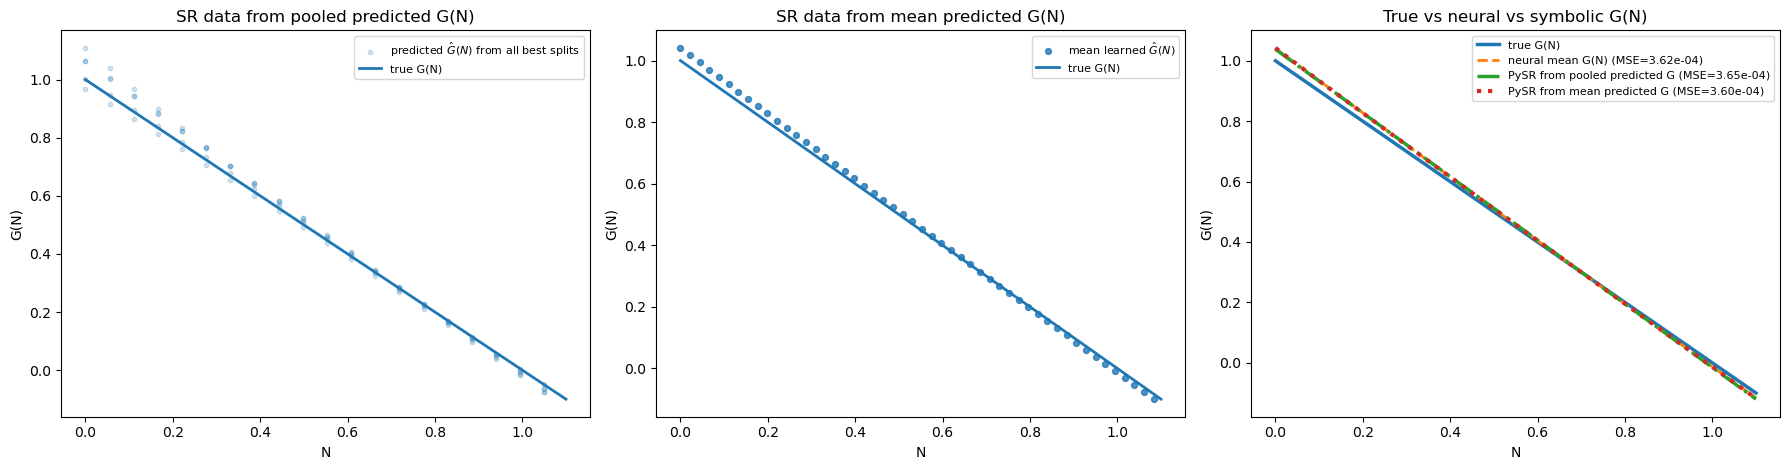

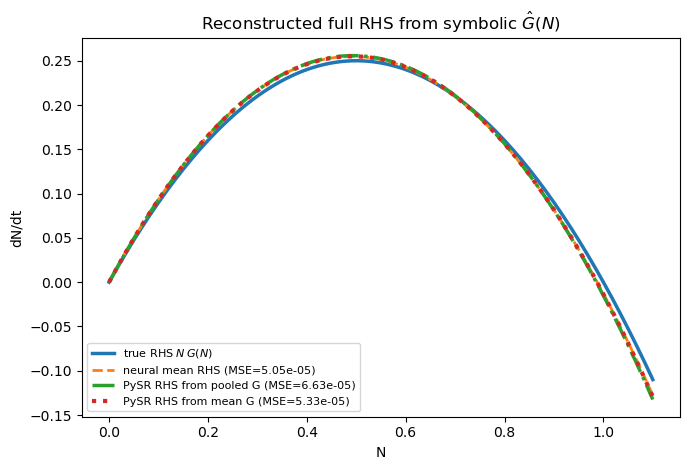


Selected equation from pooled predicted G(N):
complexity                                             5
loss                                            0.000008
equation                      1.038014 - (x0 * 1.053142)
score                                           1.817789
sympy_format                      1.038014 - 1.053142*x0
lambda_format    PySRFunction(X=>1.038014 - 1.053142*x0)
Name: 2, dtype: object

Selected equation from mean predicted G(N):
complexity                                                       7
loss                                                      0.000001
equation               ((x0 ^ 0.9871171) * -1.0561085) + 1.0426738
score                                                     0.868428
sympy_format                1.0426738 + x0**0.9871171*(-1.0561085)
lambda_format    PySRFunction(X=>1.0426738 + x0**0.9871171*(-1....
Name: 3, dtype: object
  - outputs/20260311_155129_fntCFV/hall_of_fame.csv


In [12]:
# ============================================================
# 13. Symbolic regression (PySR) directly on predicted G(N)
#
# Instead of constructing targets from u_t or dN/dt,
# this fits symbolic regression directly to the learned
# reduced-factor predictions G_hat(N) from the dyn_nets.
#
# Dataset:
#   X = N
#   y = predicted G(N)
#
# Two SR fits are performed:
#   (A) pooled split-wise predictions on N_grid
#   (B) mean learned curve gfactor_mean on N_grid
#
# Both are compared to the true G(N)=r(1-N).
#
# Requirement:
#   pip install pysr
# ============================================================

from pysr import PySRRegressor
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper: rebuild a trained dyn_net from saved state
# ------------------------------------------------------------
def rebuild_dynnet(best_state, hidden_dim_dyn, device):
    net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)
    net.load_state_dict(best_state["dyn_net"])
    net.eval()
    return net


# ------------------------------------------------------------
# Helper: collect SR data directly from learned dyn_net predictions
#
# If use_all_splits=True:
#   pool predictions from every best split on N_eval
#
# If use_all_splits=False:
#   use only the best-validation split
# ------------------------------------------------------------
def collect_sr_data_from_predicted_g(best_states, best_val_losses, N_eval, hidden_dim_dyn, device, use_all_splits=True):
    X_all = []
    y_all = []

    if use_all_splits:
        split_indices = list(range(len(best_states)))
    else:
        split_indices = [int(np.argmin(best_val_losses))]

    with torch.no_grad():
        for split_idx in split_indices:
            dyn_net = rebuild_dynnet(
                best_state=best_states[split_idx],
                hidden_dim_dyn=hidden_dim_dyn,
                device=device,
            )
            G_pred = dyn_net(N_eval).detach().cpu().numpy().reshape(-1)
            N_np = N_eval.detach().cpu().numpy().reshape(-1)

            mask = np.isfinite(N_np) & np.isfinite(G_pred)
            X_all.append(N_np[mask].reshape(-1, 1))
            y_all.append(G_pred[mask].reshape(-1))

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.concatenate(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: collect SR data from the mean learned curve
# ------------------------------------------------------------
def collect_sr_data_from_mean_gcurve(N_eval, gfactor_mean):
    X = N_eval.detach().cpu().numpy().reshape(-1, 1)
    y = np.asarray(gfactor_mean).reshape(-1)

    mask = np.isfinite(X[:, 0]) & np.isfinite(y)
    return X[mask], y[mask]


# ------------------------------------------------------------
# Helper: fit PySR
# ------------------------------------------------------------
def fit_pysr_1d(X, y, niterations=200, populations=20, maxsize=18, random_state=0):
    model = PySRRegressor(
        niterations=niterations,
        populations=populations,
        population_size=50,
        maxsize=maxsize,
        model_selection="best",
        loss="loss(prediction, target) = (prediction - target)^2",
        binary_operators=["+", "-", "*", "/", "^"],
        unary_operators=["exp", "log", "sqrt", "tanh"],
        batching=False,
        turbo=True,
        progress=True,
        random_state=random_state,
        deterministic=True,
        parallelism="serial",
        denoise=True,
        warm_start=False,
    )
    model.fit(X, y)
    return model


# ------------------------------------------------------------
# Helper: safe prediction
# ------------------------------------------------------------
def safe_predict(model, X):
    y = model.predict(X)
    return np.asarray(y).reshape(-1)


# ------------------------------------------------------------
# Build SR datasets directly from predicted G(N)
# ------------------------------------------------------------
X_g_pooled, y_g_pooled = collect_sr_data_from_predicted_g(
    best_states=best_states,
    best_val_losses=best_val_losses,
    N_eval=N_grid,
    hidden_dim_dyn=hidden_dim_dyn,
    device=device,
    use_all_splits=True,   # pooled from all best splits
)

X_g_mean, y_g_mean = collect_sr_data_from_mean_gcurve(
    N_eval=N_grid,
    gfactor_mean=gfactor_mean,
)

X_g_pooled = X_g_pooled[::10]
y_g_pooled = y_g_pooled[::10]
X_g_mean = X_g_mean[::4]
y_g_mean = y_g_mean[::4]


print("\nSR dataset sizes (directly from predicted G)")
print("--------------------------------------------")
print(f"Pooled split-wise predicted G: X shape = {X_g_pooled.shape}, y shape = {y_g_pooled.shape}")
print(f"Mean learned G curve         : X shape = {X_g_mean.shape}, y shape = {y_g_mean.shape}")


# ------------------------------------------------------------
# Fit PySR models
# ------------------------------------------------------------
pysr_g_pooled = fit_pysr_1d(
    X_g_pooled,
    y_g_pooled,
    niterations=40,
    populations=20,
    maxsize=7,
    random_state=123,
)

pysr_g_mean = fit_pysr_1d(
    X_g_mean,
    y_g_mean,
    niterations=40,
    populations=20,
    maxsize=7,
    random_state=456,
)

print("\nBest symbolic model from pooled predicted G(N)")
print("----------------------------------------------")
print(pysr_g_pooled)

print("\nBest symbolic model from mean predicted G(N)")
print("--------------------------------------------")
print(pysr_g_mean)


# ------------------------------------------------------------
# Evaluate symbolic models on N_grid
# ------------------------------------------------------------
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
N_grid_flat = N_grid_np[:, 0]

G_true_np = G_true(N_grid).detach().cpu().numpy().reshape(-1)

G_sr_pooled_np = safe_predict(pysr_g_pooled, N_grid_np)
G_sr_mean_np = safe_predict(pysr_g_mean, N_grid_np)

RHS_sr_pooled_np = N_grid_flat * G_sr_pooled_np
RHS_sr_mean_np = N_grid_flat * G_sr_mean_np

mse_nn_G = np.mean((gfactor_mean - G_true_np) ** 2)
mse_sr_pooled_G = np.mean((G_sr_pooled_np - G_true_np) ** 2)
mse_sr_mean_G = np.mean((G_sr_mean_np - G_true_np) ** 2)

mse_nn_rhs = np.mean((rhs_mean - RHS_true(N_grid).detach().cpu().numpy().reshape(-1)) ** 2)
mse_sr_pooled_rhs = np.mean((RHS_sr_pooled_np - RHS_true(N_grid).detach().cpu().numpy().reshape(-1)) ** 2)
mse_sr_mean_rhs = np.mean((RHS_sr_mean_np - RHS_true(N_grid).detach().cpu().numpy().reshape(-1)) ** 2)

print("\nMSE on N_grid against true G(N)")
print("-------------------------------")
print(f"Neural mean G(N) MSE              : {mse_nn_G:.6e}")
print(f"PySR from pooled predicted G MSE  : {mse_sr_pooled_G:.6e}")
print(f"PySR from mean predicted G MSE    : {mse_sr_mean_G:.6e}")

print("\nMSE on N_grid against true RHS = N*G(N)")
print("---------------------------------------")
print(f"Neural mean RHS MSE               : {mse_nn_rhs:.6e}")
print(f"PySR from pooled predicted G MSE  : {mse_sr_pooled_rhs:.6e}")
print(f"PySR from mean predicted G MSE    : {mse_sr_mean_rhs:.6e}")


# ------------------------------------------------------------
# Plot SR datasets and final recovered G(N)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Pooled predicted G data
axes[0].scatter(
    X_g_pooled[:, 0],
    y_g_pooled,
    s=10,
    alpha=0.20,
    label=r"predicted $\hat G(N)$ from all best splits",
)
axes[0].plot(
    N_grid_flat,
    G_true_np,
    linewidth=2,
    label="true G(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("G(N)")
axes[0].set_title("SR data from pooled predicted G(N)")
axes[0].legend(fontsize=8)

# Mean learned G curve
axes[1].scatter(
    X_g_mean[:, 0],
    y_g_mean,
    s=18,
    alpha=0.8,
    label=r"mean learned $\hat G(N)$",
)
axes[1].plot(
    N_grid_flat,
    G_true_np,
    linewidth=2,
    label="true G(N)",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("G(N)")
axes[1].set_title("SR data from mean predicted G(N)")
axes[1].legend(fontsize=8)

# Final comparison
axes[2].plot(
    N_grid_flat,
    G_true_np,
    linewidth=2.5,
    label="true G(N)",
)
axes[2].plot(
    N_grid_flat,
    gfactor_mean,
    "--",
    linewidth=2,
    label=f"neural mean G(N) (MSE={mse_nn_G:.2e})",
)
axes[2].plot(
    N_grid_flat,
    G_sr_pooled_np,
    "-.",
    linewidth=2.5,
    label=f"PySR from pooled predicted G (MSE={mse_sr_pooled_G:.2e})",
)
axes[2].plot(
    N_grid_flat,
    G_sr_mean_np,
    ":",
    linewidth=3.0,
    label=f"PySR from mean predicted G (MSE={mse_sr_mean_G:.2e})",
)
axes[2].set_xlabel("N")
axes[2].set_ylabel("G(N)")
axes[2].set_title("True vs neural vs symbolic G(N)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optional: compare reconstructed RHS
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.8))
plt.plot(
    N_grid_flat,
    RHS_true(N_grid).detach().cpu().numpy().reshape(-1),
    linewidth=2.5,
    label=r"true RHS $N\,G(N)$",
)
plt.plot(
    N_grid_flat,
    rhs_mean,
    "--",
    linewidth=2,
    label=f"neural mean RHS (MSE={mse_nn_rhs:.2e})",
)
plt.plot(
    N_grid_flat,
    RHS_sr_pooled_np,
    "-.",
    linewidth=2.5,
    label=f"PySR RHS from pooled G (MSE={mse_sr_pooled_rhs:.2e})",
)
plt.plot(
    N_grid_flat,
    RHS_sr_mean_np,
    ":",
    linewidth=3.0,
    label=f"PySR RHS from mean G (MSE={mse_sr_mean_rhs:.2e})",
)
plt.xlabel("N")
plt.ylabel("dN/dt")
plt.title(r"Reconstructed full RHS from symbolic $\hat G(N)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optional: print the selected equations more explicitly
# ------------------------------------------------------------
try:
    print("\nSelected equation from pooled predicted G(N):")
    print(pysr_g_pooled.get_best())

    print("\nSelected equation from mean predicted G(N):")
    print(pysr_g_mean.get_best())
except Exception as e:
    print("\nCould not print get_best() details.")
    print(f"Reason: {e}")


Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.10
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
Initial a for split 1: 1.000000
Initial b for split 1: 1.000000
PINN | Split  1/5 | Epoch     1/3000 | PINN Total: 7.285106e-01 | Optim Total: 7.285106e-01 | Train Data: 7.140545e-01 | Train Phys: 1.445608e-02 | Train IC[N(0)]: 3.013249e-02 | a: 0.999000 | b: 0.999000 | Heldout Rollout Val: 6.864571e-03
PINN | Split  1/5 | Epoch   500/3000 | PINN Total: 4.689699e-03 | Optim Total: 4.689699e-03 | Train Data: 4.450799e-03 | Train Phys: 2.388997e-04 | Train IC[N(0)]: 1.211718e-04 | a: 0.934375 | b: 1.003227 | Heldout Rollout Val: 9.557334e-03
PINN | Split  1/5 | Epoch  1000/3000 | PINN Total: 4.435922e-03 | Optim Total: 4.435922e-03 | Train Data: 4.240069e-03 | Train Phys: 1.958540e-04 | Train IC[N(0)]: 8.545502e-05 | a: 0.972776 | b: 0.997919 | Heldout Rollout Val: 7.97018

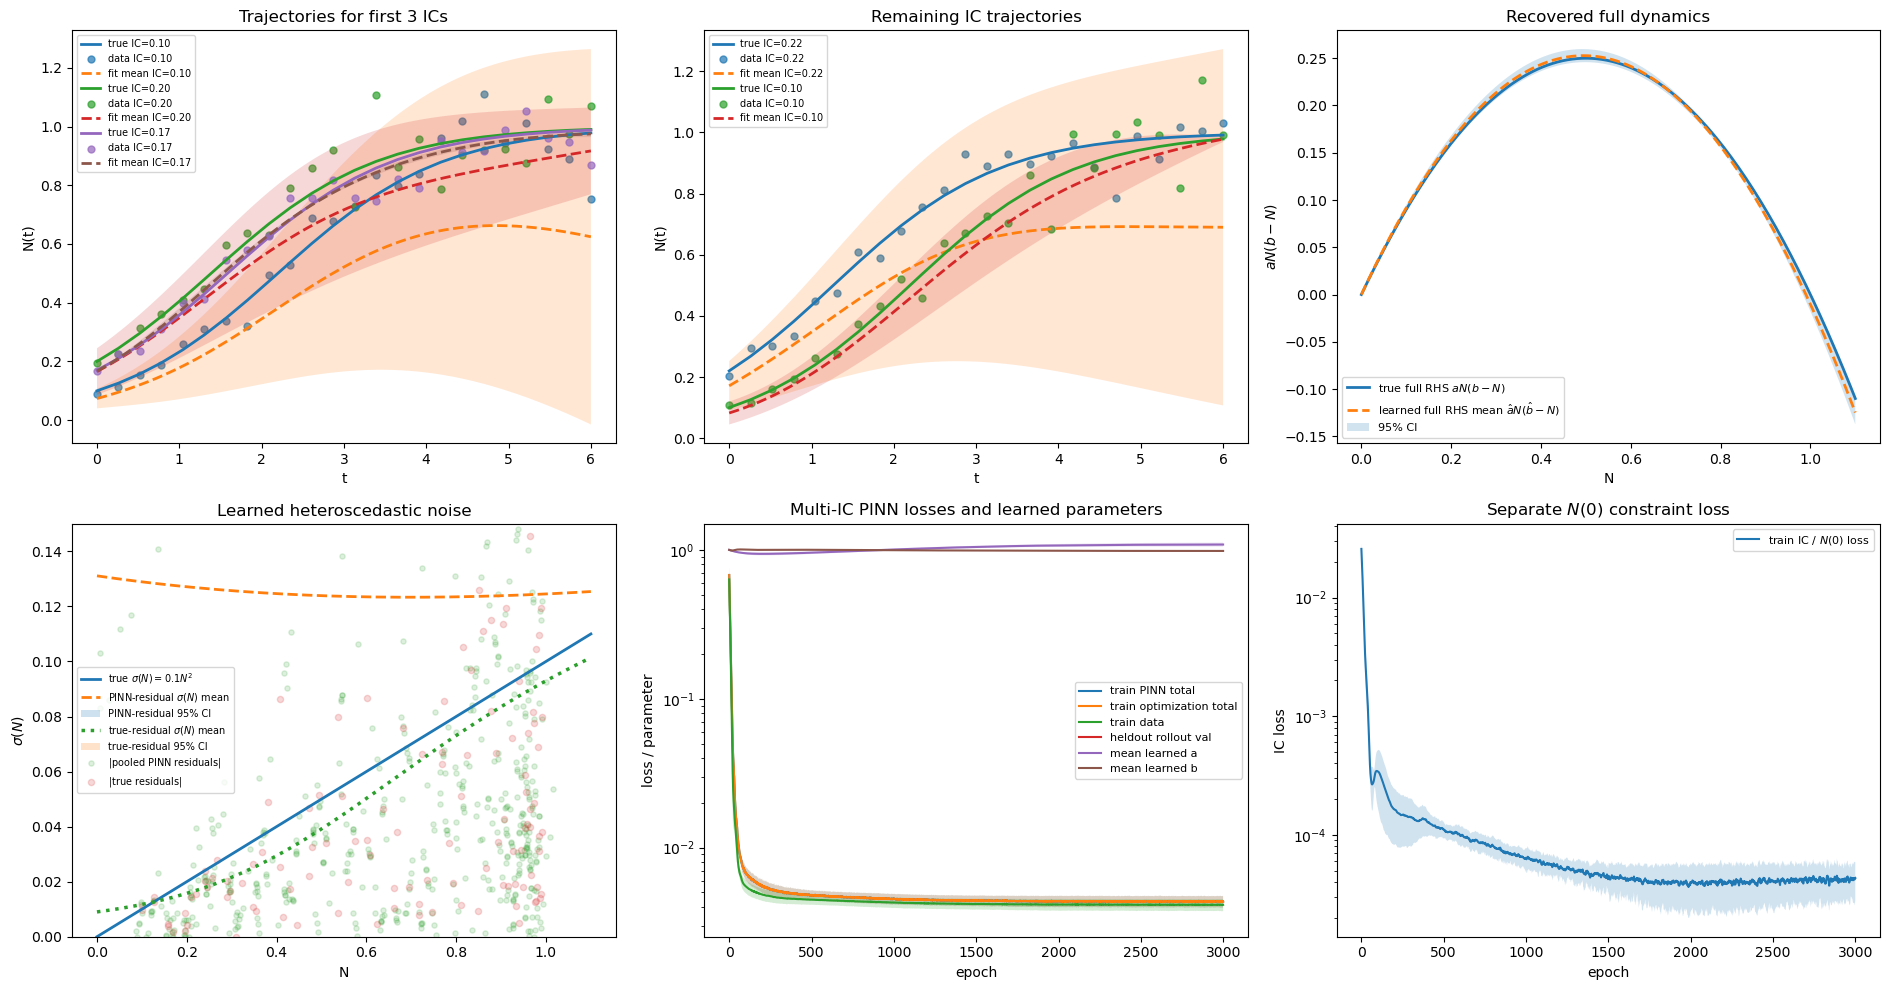

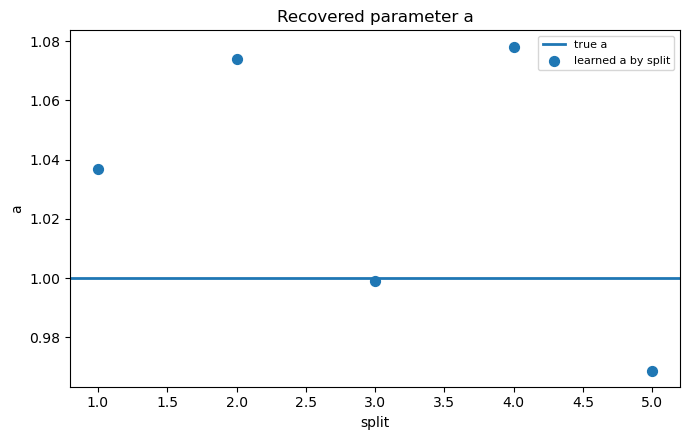

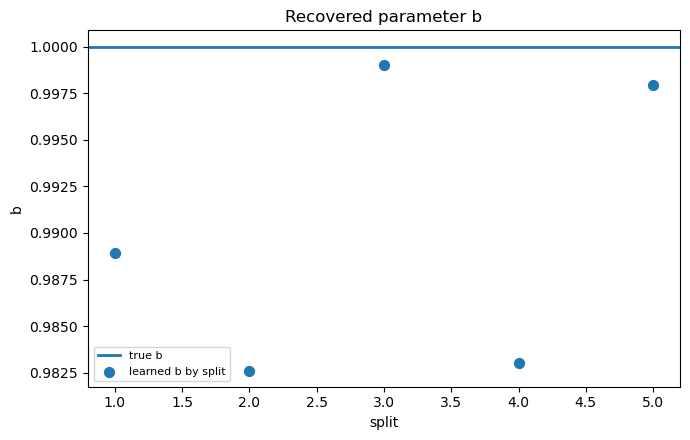

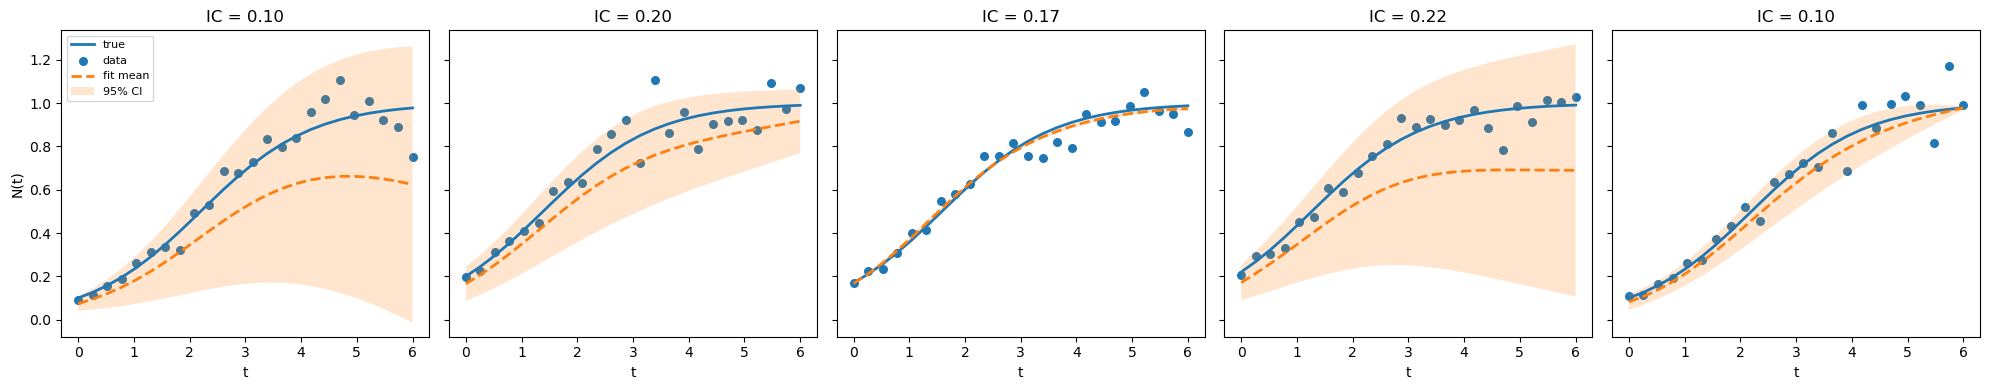

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_17962/1957748521.py:778: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


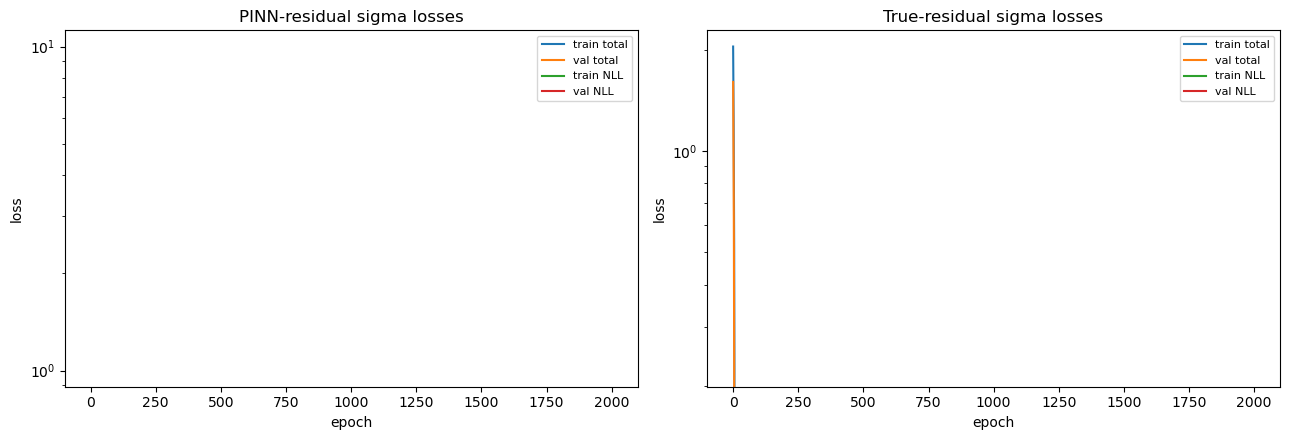

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 5
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22, 0.1]
Number of PINN splits: 5
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 4.826763e-03
Std  best validation loss: 1.815794e-03
Mean best epoch: 1759.20
Std  best epoch: 1562.73
Mean learned a across splits: 1.031403
Std  learned a across splits: 0.047470
Mean learned b across splits: 0.990307
Std  learned b across splits: 0.007862
True a: 1.000000
True b: 1.000000
IC/N(0) loss weight lambda_ic: 0.000
Model structure: dN/dt = a * N * (b - N)
PINN loss used for model fitting/selection: data + lambda_phys * physics
Separate optimization term: lambda_ic * IC/N(0) loss

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003, 20004], a_best=1

In [13]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# True dynamics for RHS structure dN/dt = a_true * N * (b_true - N)
# ============================================================
a_true = 1.0
b_true = 1.0

def RHS_true(N):
    return a_true * N * (b_true - N)


# ============================================================
# Trainable scalar-only dynamics model: RHS(N) = a * N * (b - N)
# ============================================================
class DynamicsParams(nn.Module):
    def __init__(self, a_init=1.0, b_init=1.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(float(a_init)))
        self.b = nn.Parameter(torch.tensor(float(b_init)))

    def forward(self, N):
        return self.a * N * (self.b - N)


def pinn_physics_residual(sol_net, dyn_model, t_col):
    """
    Model structure:
        dN/dt = a * N * (b - N)
    where dyn_model has trainable scalars a and b only.
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]

    rhs_pred = dyn_model(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res


def rhs_parameter_penalty(dyn_model):
    """
    Optional soft constraints:
      - a >= 0
      - b >= 0
    """
    pen_a = torch.relu(-dyn_model.a) ** 2
    pen_b = torch.relu(-dyn_model.b) ** 2
    return pen_a + pen_b


@torch.no_grad()
def rollout_with_learned_rhs(dyn_model, y0, t):
    """
    Forward solve dN/dt = a * N * (b - N)
    from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(
        lambda tt, yy: dyn_model(yy),
        y0,
        t.squeeze(),
    ).squeeze(1)
    return y_roll


# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared scalar-param dynamics model learning a,b
#    - full RHS is a * N * (b - N)
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - N(0) constraint treated as separate loss term
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 3000
n_splits = n_ics
print_every = 500
val_every = 100

batch_obs = t_obs.shape[0]
batch_col = 100

lambda_phys = 1.0
lambda_ic = 0.0
lambda_a_reg = 0.0
lambda_b_reg = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32

dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_pinn_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_optim_total_histories = []

a_histories = []
b_histories = []

val_total_histories = []
val_eval_mask_histories = []

traj_histories = []
rhs_histories = []
a_learned_per_split = []
b_learned_per_split = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_model = DynamicsParams(a_init=1.0, b_init=1.0).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")
    print(f"Initial a for split {split + 1}: {dyn_model.a.detach().item():.6f}")
    print(f"Initial b for split {split + 1}: {dyn_model.b.detach().item():.6f}")

    optimizer = torch.optim.Adam(
        list(dyn_model.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_pinn_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_optim_total_history = []
    a_history = []
    b_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_ic_loss = 0.0

        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_model, t_col)

            phys_loss = torch.mean(phys_res ** 2)
            phys_loss = phys_loss + rhs_parameter_penalty(dyn_model)
            phys_loss = phys_loss + lambda_a_reg * (dyn_model.a ** 2)
            phys_loss = phys_loss + lambda_b_reg * (dyn_model.b ** 2)

            t0 = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
            y0_target = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0)
            ic_loss = torch.mean((N0_pred - y0_target) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_ic_loss += ic_loss

        total_data_loss /= n_train_ics
        total_phys_loss /= n_train_ics
        total_ic_loss /= n_train_ics

        pinn_loss = total_data_loss + lambda_phys * total_phys_loss
        optim_loss = pinn_loss + lambda_ic * total_ic_loss

        optim_loss.backward()
        optimizer.step()

        train_pinn_total_history.append(pinn_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_ic_history.append(total_ic_loss.item())
        train_optim_total_history.append(optim_loss.item())
        a_history.append(dyn_model.a.detach().item())
        b_history.append(dyn_model.b.detach().item())

        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_model.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                y0_val = y_data_all[heldout_ic][0:1]
                y_val_target = y_data_all[heldout_ic]
                y_val_roll = rollout_with_learned_rhs(dyn_model, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_model": copy.deepcopy(dyn_model.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                    "a_best": float(dyn_model.a.detach().cpu().item()),
                    "b_best": float(dyn_model.b.detach().cpu().item()),
                }

            dyn_model.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"PINN Total: {pinn_loss.item():.6e} | "
                f"Optim Total: {optim_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train IC[N(0)]: {total_ic_loss.item():.6e} | "
                f"a: {dyn_model.a.detach().item():.6f} | "
                f"b: {dyn_model.b.detach().item():.6f} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e} | "
        f"Best a = {best_state['a_best']:.6f} | "
        f"Best b = {best_state['b_best']:.6f}"
    )

    dyn_model.load_state_dict(best_state["dyn_model"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_model.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_model, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_model, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        N_grid_np = N_grid.squeeze(1).cpu().numpy()
        a_learned = dyn_model.a.detach().cpu().item()
        b_learned = dyn_model.b.detach().cpu().item()
        rhs_grid_learned = a_learned * N_grid_np * (b_learned - N_grid_np)

    train_pinn_total_histories.append(train_pinn_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_optim_total_histories.append(train_optim_total_history)
    a_histories.append(a_history)
    b_histories.append(b_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(rhs_grid_learned)
    a_learned_per_split.append(a_learned)
    b_learned_per_split.append(b_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_pinn_total_histories = np.array(train_pinn_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_optim_total_histories = np.array(train_optim_total_histories)
a_histories = np.array(a_histories)
b_histories = np.array(b_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
a_learned_per_split = np.array(a_learned_per_split)
b_learned_per_split = np.array(b_learned_per_split)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

axes[0, 2].plot(
    N_grid.cpu().numpy(),
    RHS_true(N_grid).squeeze(1).cpu().numpy(),
    label=r"true full RHS $aN(b-N)$",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label=r"learned full RHS mean $\hat a N(\hat b-N)$",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel(r"$aN(b-N)$")
axes[0, 2].set_title("Recovered full dynamics")
axes[0, 2].legend(fontsize=8)

axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

epochs_init = np.arange(n_epochs)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(train_pinn_total_histories)
train_optim_total_mean, train_optim_total_lo, train_optim_total_hi = mean_and_ci(train_optim_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
a_mean, a_lo, a_hi = mean_and_ci(a_histories)
b_mean, b_lo, b_hi = mean_and_ci(b_histories)

axes[1, 1].plot(epochs_init, train_pinn_total_mean, label="train PINN total")
axes[1, 1].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_optim_total_mean, label="train optimization total")
axes[1, 1].fill_between(epochs_init, train_optim_total_lo, train_optim_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, a_mean, label="mean learned a")
axes[1, 1].fill_between(epochs_init, a_lo, a_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, b_mean, label="mean learned b")
axes[1, 1].fill_between(epochs_init, b_lo, b_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss / parameter")
axes[1, 1].set_title("Multi-IC PINN losses and learned parameters")
axes[1, 1].legend(fontsize=8)

train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
axes[1, 2].plot(epochs_init, train_ic_mean, label=r"train IC / $N(0)$ loss")
axes[1, 2].fill_between(epochs_init, train_ic_lo, train_ic_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("IC loss")
axes[1, 2].set_title(r"Separate $N(0)$ constraint loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.axhline(a_true, linewidth=2, label="true a")
plt.scatter(np.arange(1, n_splits + 1), a_learned_per_split, s=50, label="learned a by split")
plt.xlabel("split")
plt.ylabel("a")
plt.title("Recovered parameter a")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.axhline(b_true, linewidth=2, label="true b")
plt.scatter(np.arange(1, n_splits + 1), b_learned_per_split, s=50, label="learned b by split")
plt.xlabel("split")
plt.ylabel("b")
plt.title("Recovered parameter b")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Mean learned a across splits: {np.mean(a_learned_per_split):.6f}")
print(f"Std  learned a across splits: {np.std(a_learned_per_split, ddof=1):.6f}")
print(f"Mean learned b across splits: {np.mean(b_learned_per_split):.6f}")
print(f"Std  learned b across splits: {np.std(b_learned_per_split, ddof=1):.6f}")
print(f"True a: {a_true:.6f}")
print(f"True b: {b_true:.6f}")
print(f"IC/N(0) loss weight lambda_ic: {lambda_ic:.3f}")
print("Model structure: dN/dt = a * N * (b - N)")
print("PINN loss used for model fitting/selection: data + lambda_phys * physics")
print("Separate optimization term: lambda_ic * IC/N(0) loss")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"a_best={st['a_best']:.6f}, "
        f"b_best={st['b_best']:.6f}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )


Starting PINN split 1/5
Held-out validation trajectory index: 0 | IC = 0.10
Training trajectory indices: [1, 2, 3, 4]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003, 20004]
Initial a for split 1: 1.000000
PINN | Split  1/5 | Epoch     1/3000 | PINN Total: 7.144223e-01 | Optim Total: 7.144223e-01 | Train Data: 7.140545e-01 | Train Phys: 3.678447e-04 | Train IC[N(0)]: 3.013249e-02 | a: 0.999000 | Heldout Rollout Val: 2.672647e-01
PINN | Split  1/5 | Epoch   500/3000 | PINN Total: 4.637130e-03 | Optim Total: 4.637130e-03 | Train Data: 4.372535e-03 | Train Phys: 2.645945e-04 | Train IC[N(0)]: 1.451196e-04 | a: 1.064878 | Heldout Rollout Val: 6.604639e-03
PINN | Split  1/5 | Epoch  1000/3000 | PINN Total: 4.415835e-03 | Optim Total: 4.415835e-03 | Train Data: 4.207273e-03 | Train Phys: 2.085620e-04 | Train IC[N(0)]: 1.745577e-04 | a: 1.044203 | Heldout Rollout Val: 6.395915e-03
PINN | Split  1/5 | Epoch  1500/3000 | PINN Total: 4.278340e-03 | Op

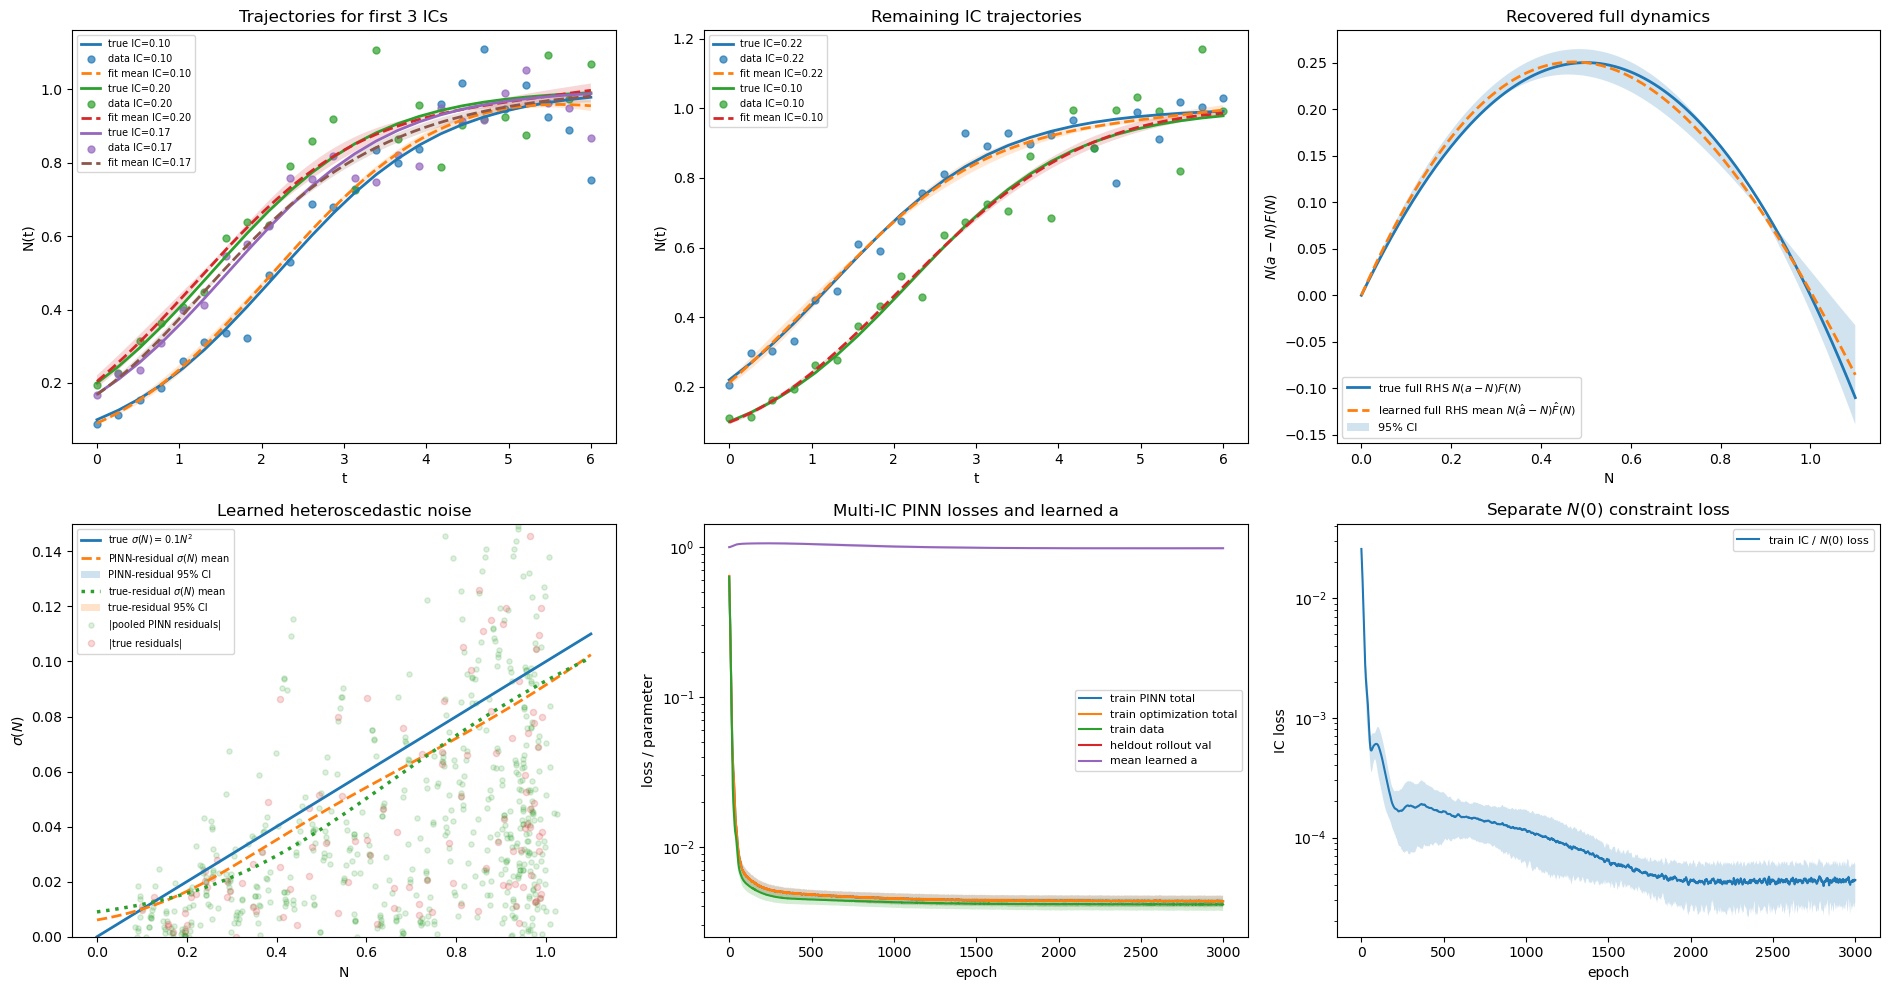

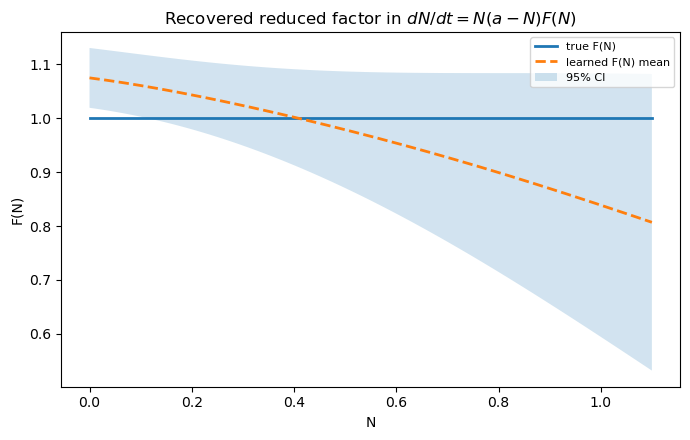

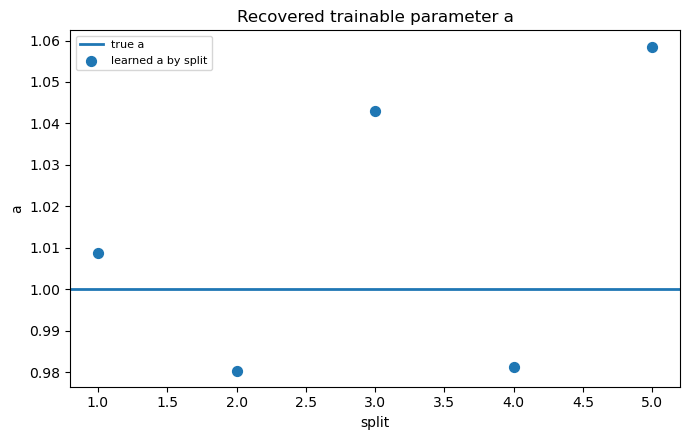

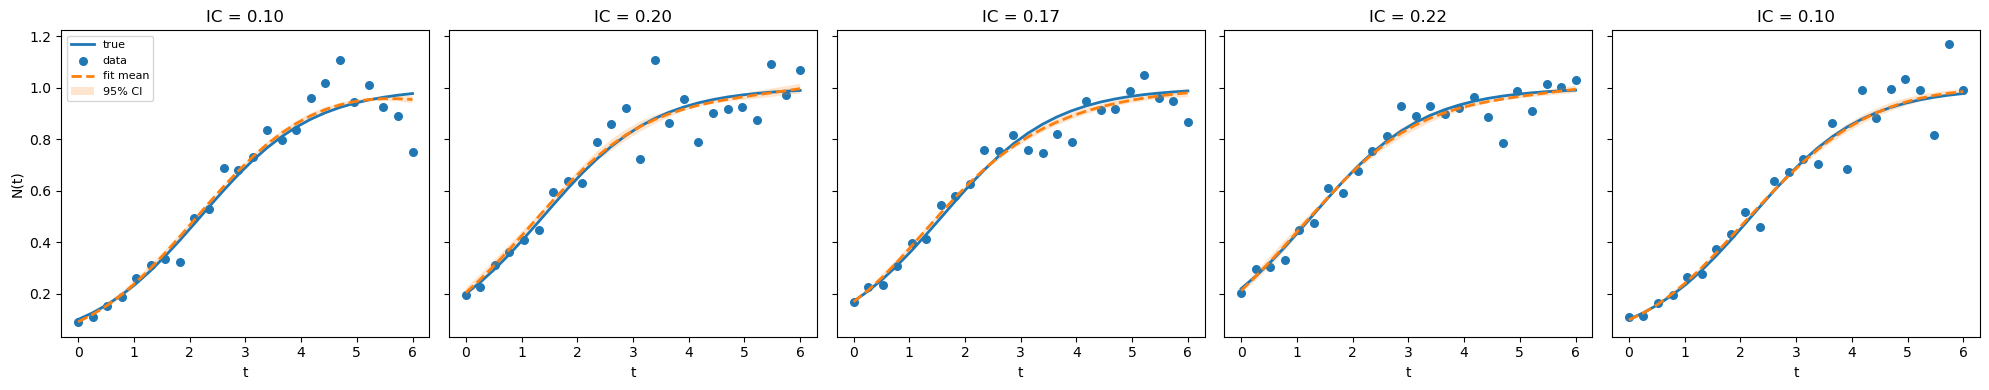

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_13760/1304087113.py:794: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


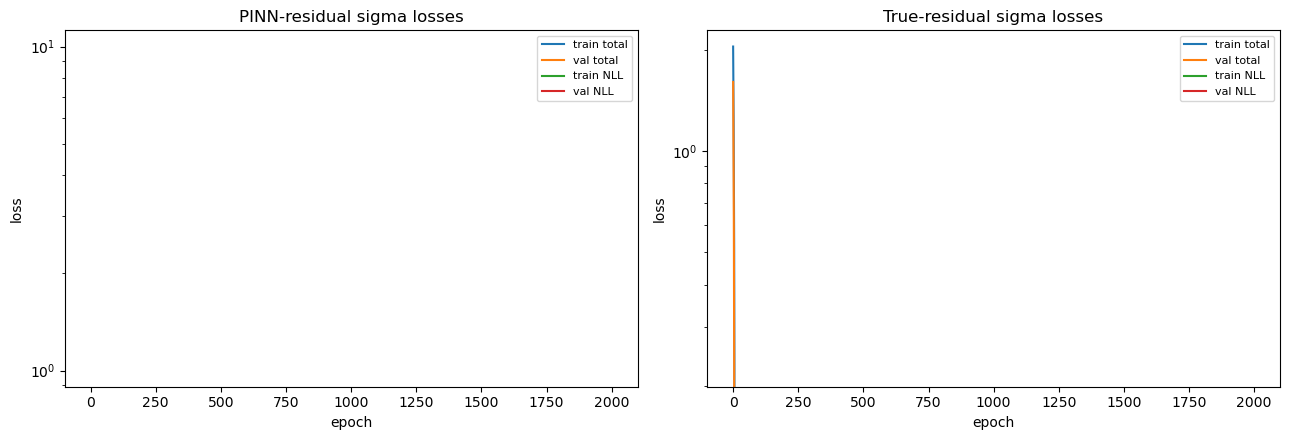

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 5
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22, 0.1]
Number of PINN splits: 5
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 4.851942e-03
Std  best validation loss: 1.833606e-03
Mean best epoch: 1399.00
Std  best epoch: 1126.94
Mean learned a across splits: 1.014402
Std  learned a across splits: 0.035567
True a: 1.000000
IC/N(0) loss weight lambda_ic: 0.000
Model structure: dN/dt = N * (a - N) * F(N), with dyn_net learning F(N)
PINN loss used for model fitting/selection: data + lambda_phys * physics
Separate optimization term: lambda_ic * IC/N(0) loss

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003, 20004], a_best=1.008713
Split 2: heldout_ic=1, dyn_init_seed=10001, sol_init_see

In [38]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# True dynamics for RHS structure dN/dt = N * (a_true - N) * F(N)
# ============================================================
r_true = 1.0
a_true = 1.0

class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32, a_init=1.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(float(a_init)))
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)   # this is F(N)
    
def F_true(N):
    # logistic-compatible choice:
    # dN/dt = r_true * N * (1 - N)
    # written as dN/dt = N * (a_true - N) * F(N)
    # so when a_true = 1, F_true(N) = r_true
    return r_true * torch.ones_like(N)

def RHS_true(N):
    # full RHS
    return N * (a_true - N) * F_true(N)


def pinn_physics_residual(sol_net, dyn_net, t_col):
    """
    Model structure:
        dN/dt = N * (a - N) * F(N)
    where:
        dyn_net(N) approximates the reduced factor F(N),
        dyn_net.a is the trainable scalar a.
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]

    f_pred = dyn_net(N_pred_col)
    a_param = dyn_net.a
    rhs_pred = N_pred_col * (a_param - N_pred_col) * f_pred
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, f_pred, rhs_pred, phys_res


def rhs_zero_structure_penalty(dyn_net):
    """
    Optional penalty to keep a >= 0.
    The full RHS is automatically zero at N=0 and N=a because of the factorization.
    """
    return torch.relu(-dyn_net.a) ** 2


@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = N * (a - N) * dyn_net(N)
    from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    a_param = dyn_net.a
    y_roll = odeint_rk4(
        lambda tt, yy: yy * (a_param - yy) * dyn_net(yy),
        y0,
        t.squeeze(),
    ).squeeze(1)
    return y_roll


# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net learning the reduced factor F(N)
#    - full RHS is N * (a - N) * F(N)
#    - trainable scalar a is inside dyn_net
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - N(0) constraint treated as separate loss term
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 3000
n_splits = n_ics
print_every = 500
val_every = 100

batch_obs = t_obs.shape[0]
batch_col = 100

lambda_phys = 1.0
lambda_ic = 0.0
lambda_a_reg = 0.0   # optional regularization on a if desired
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_pinn_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_optim_total_histories = []
a_histories = []

val_total_histories = []
val_eval_mask_histories = []

traj_histories = []
rhs_histories = []         # full RHS = N*(a-N)*F(N)
ffactor_histories = []     # reduced factor = F(N)
a_learned_per_split = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")
    print(f"Initial a for split {split + 1}: {dyn_net.a.detach().item():.6f}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_pinn_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_optim_total_history = []
    a_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_ic_loss = 0.0

        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)
            phys_loss = phys_loss + rhs_zero_structure_penalty(dyn_net)
            phys_loss = phys_loss + lambda_a_reg * (dyn_net.a ** 2)

            t0 = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
            y0_target = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0)
            ic_loss = torch.mean((N0_pred - y0_target) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_ic_loss += ic_loss

        total_data_loss /= n_train_ics
        total_phys_loss /= n_train_ics
        total_ic_loss /= n_train_ics

        pinn_loss = total_data_loss + lambda_phys * total_phys_loss
        optim_loss = pinn_loss + lambda_ic * total_ic_loss

        optim_loss.backward()
        optimizer.step()

        train_pinn_total_history.append(pinn_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_ic_history.append(total_ic_loss.item())
        train_optim_total_history.append(optim_loss.item())
        a_history.append(dyn_net.a.detach().item())

        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                y0_val = y_data_all[heldout_ic][0:1]
                y_val_target = y_data_all[heldout_ic]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                    "a_best": float(dyn_net.a.detach().cpu().item()),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"PINN Total: {pinn_loss.item():.6e} | "
                f"Optim Total: {optim_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train IC[N(0)]: {total_ic_loss.item():.6e} | "
                f"a: {dyn_net.a.detach().item():.6f} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e} | "
        f"Best a = {best_state['a_best']:.6f}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        F_factor_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()
        a_learned = dyn_net.a.detach().cpu().item()
        rhs_grid_learned = N_grid.squeeze(1).cpu().numpy() * (a_learned - N_grid.squeeze(1).cpu().numpy()) * F_factor_grid_learned

    train_pinn_total_histories.append(train_pinn_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_optim_total_histories.append(train_optim_total_history)
    a_histories.append(a_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(rhs_grid_learned)
    ffactor_histories.append(F_factor_grid_learned)
    a_learned_per_split.append(a_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_pinn_total_histories = np.array(train_pinn_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_optim_total_histories = np.array(train_optim_total_histories)
a_histories = np.array(a_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
ffactor_histories = np.array(ffactor_histories)
a_learned_per_split = np.array(a_learned_per_split)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
ffactor_mean, ffactor_lo, ffactor_hi = mean_and_ci(ffactor_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

axes[0, 2].plot(
    N_grid.cpu().numpy(),
    RHS_true(N_grid).squeeze(1).cpu().numpy(),
    label=r"true full RHS $N(a-N)F(N)$",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label=r"learned full RHS mean $N(\hat a-N)\hat F(N)$",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel(r"$N(a-N)F(N)$")
axes[0, 2].set_title("Recovered full dynamics")
axes[0, 2].legend(fontsize=8)

axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

epochs_init = np.arange(n_epochs)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(train_pinn_total_histories)
train_optim_total_mean, train_optim_total_lo, train_optim_total_hi = mean_and_ci(train_optim_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
a_mean, a_lo, a_hi = mean_and_ci(a_histories)

axes[1, 1].plot(epochs_init, train_pinn_total_mean, label="train PINN total")
axes[1, 1].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_optim_total_mean, label="train optimization total")
axes[1, 1].fill_between(epochs_init, train_optim_total_lo, train_optim_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, a_mean, label="mean learned a")
axes[1, 1].fill_between(epochs_init, a_lo, a_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss / parameter")
axes[1, 1].set_title("Multi-IC PINN losses and learned a")
axes[1, 1].legend(fontsize=8)

train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
axes[1, 2].plot(epochs_init, train_ic_mean, label=r"train IC / $N(0)$ loss")
axes[1, 2].fill_between(epochs_init, train_ic_lo, train_ic_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("IC loss")
axes[1, 2].set_title(r"Separate $N(0)$ constraint loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(
    N_grid.cpu().numpy(),
    F_true(N_grid).squeeze(1).cpu().numpy(),
    linewidth=2,
    label="true F(N)",
)
plt.plot(
    N_grid.cpu().numpy(),
    ffactor_mean,
    "--",
    linewidth=2,
    label="learned F(N) mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    ffactor_lo,
    ffactor_hi,
    alpha=0.20,
    label="95% CI",
)
plt.xlabel("N")
plt.ylabel("F(N)")
plt.title(r"Recovered reduced factor in $dN/dt = N(a-N)F(N)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.axhline(a_true, linewidth=2, label="true a")
plt.scatter(np.arange(1, n_splits + 1), a_learned_per_split, s=50, label="learned a by split")
plt.xlabel("split")
plt.ylabel("a")
plt.title("Recovered trainable parameter a")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Mean learned a across splits: {np.mean(a_learned_per_split):.6f}")
print(f"Std  learned a across splits: {np.std(a_learned_per_split, ddof=1):.6f}")
print(f"True a: {a_true:.6f}")
print(f"IC/N(0) loss weight lambda_ic: {lambda_ic:.3f}")
print("Model structure: dN/dt = N * (a - N) * F(N), with dyn_net learning F(N)")
print("PINN loss used for model fitting/selection: data + lambda_phys * physics")
print("Separate optimization term: lambda_ic * IC/N(0) loss")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"a_best={st['a_best']:.6f}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )

best_split_idx: 3
n_ics (global): 5
best_state_for_sr keys: ['dyn_net', 'sol_nets', 'dyn_init_seed', 'sol_init_seeds', 'heldout_ic', 'train_ic_idx', 'a_best']
saved sol_nets: 4
Recovered trained a = 0.9812383652
Checkpoint contains 4 solution nets.

SR dataset sizes
----------------
From solution-net derivatives: X shape = (200, 1), y shape = (200,)
From noisy measurements       : X shape = (120, 1), y shape = (120,)


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}


Best symbolic model for F(N) from solution-net derivatives
-----------------------------------------------------------
PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          1.1583208   
	1        0.009863                                     1.2512609 ^ x0   
	2        0.284540                                 exp(x0 ^ 23.69885)   
	3        0.944383                       52.686832 ^ (x0 ^ 49.988617)   
	4        0.358849                    exp((x0 ^ 78.16411) * 8.317687)   
	5  >>>>  0.198483       ((x0 ^ 117.42048) - -0.02202236) * 45.839672   
	6        0.145691  sqrt(((x0 ^ 162.01161) * 664.41156) - -1.0182024)   
	7        0.060785  sqrt((((x0 ^ 149.80501) * 492.668) - x0) - -1....   
	
	       loss  complexity  
	0  0.351913           1  
	1  0.345039           3  
	2  0.259594           4  
	3  0.100961           5  
	4  0.070519           6  
	5  0.057824           7  
	6 

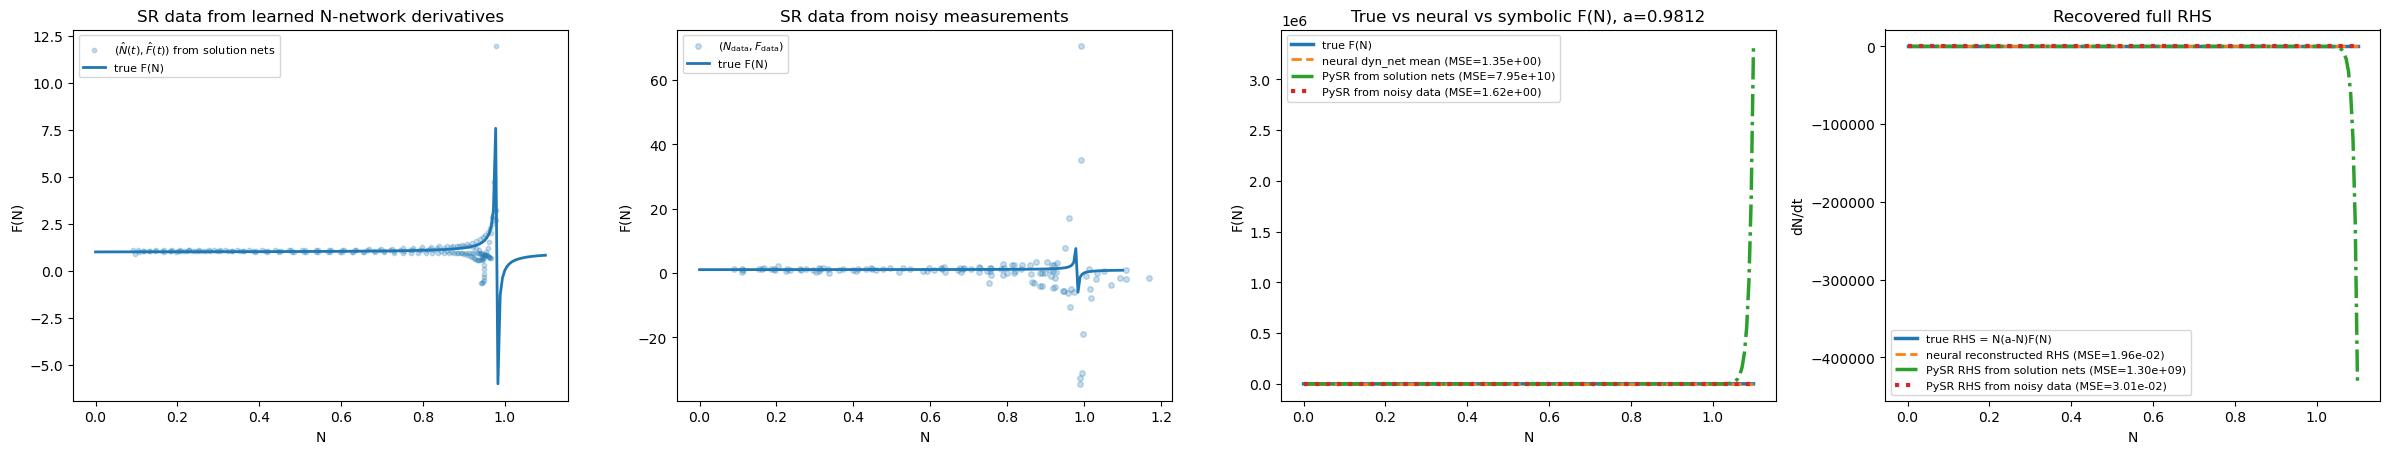


Selected equation for F(N) from solution-net derivatives:
complexity                                                       7
loss                                                      0.057824
equation              ((x0 ^ 117.42048) - -0.02202236) * 45.839672
score                                                     0.198483
sympy_format           (x0**117.42048 - 1*(-0.02202236))*45.839672
lambda_format    PySRFunction(X=>(x0**117.42048 - 1*(-0.0220223...
Name: 5, dtype: object

Selected equation for F(N) from noisy measurements:
complexity                                                   5
loss                                                  0.011034
equation                        (0.7271089 - x0) * 0.035021868
score                                                 0.004748
sympy_format                      (0.7271089 - x0)*0.035021868
lambda_format    PySRFunction(X=>(0.7271089 - x0)*0.035021868)
Name: 3, dtype: object
